**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)    
- [合成数据生成](#toc9_)    
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[文件说明（File descriptions）](#toc0_)
- train.csv - 训练集
- test.csv - 测试集
- sampleSubmission.csv - 格式正确的提交文件示例


# <a id='toc2_'></a>[数据字段（Data fields）](#toc0_)
- a - 晶胞边长a + 晶胞三个棱边长度之一，单位通常为埃（Å），表征晶胞尺寸
- b - 晶胞边长b + 晶胞三个棱边长度之二，与a、c共同决定晶胞体积，单位为埃（Å）
- c - 晶胞边长c + 晶胞三个棱边长度之三，不同晶系的a/b/c取值规则不同，单位为埃（Å）
- alpha - 晶胞角α + 晶胞中b轴与c轴的夹角，单位为度（°），取值范围0°<α<180°
- beta - 晶胞角β + 晶胞中a轴与c轴的夹角，单位为度（°），立方晶系中β=90°
- gamma - 晶胞角γ + 晶胞中a轴与b轴的夹角，单位为度（°），决定晶胞几何形态
- Space gr - 空间群（缩写） + 描述晶体对称操作的集合（如Fm-3m、Pnma），表征晶体对称性
- Space grca - 空间群衍生特征 + 推测为空间群分类/编码字段，辅助表征晶体对称特性
- Reduced CZ - 材料组成简化特征 + CZ参数的衍生简化值，用于标识材料核心组成特征
- True Com - 材料真实组成 + 材料的具体化学成分/元素配比，决定材料本质属性
- Family - 材料家族/类别 + 材料的大类归属（如氧化物、硫化物等），用于分类分析
- Ionic cor - 离子电导率（缩写） + 材料传导离子的能力，核心性能指标，单位为S/cm
- Ionic conductivity>1e-5 - 离子电导率标记 + 二值标记字段（1表示电导率>1e-5 S/cm，0表示≤1e-5 S/cm），用于区分高低电导率材料

# <a id='toc3_'></a>[导入库](#toc0_)

In [1]:
# ==========================================
# 信用违约预测（LightGBM + XGBoost + CatBoost）
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 数据合成
# 3. 五折 StratifiedKFold 训练
# 4. 加权融合 + Stacking
# 5. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & findfont 报错
# ----------------------------
import matplotlib as mpl

# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "SimHei",                # 万一你后来自己装了 SimHei
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

In [2]:
# ------------------------------------------------------------------
# Paper figures export (WHITELIST)
# 仅将⽩名单中的论⽂图表额外保存到 paper_figs/，其余⼀律不保存到该⽬录
# ------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
PAPER_FIG_DIR = "paper_figs" # 论⽂图表保存⽬录
EXP_FIG_DIR = "exp_figs" # 普通实验图表保存⽬录
os.makedirs(PAPER_FIG_DIR, exist_ok=True)
os.makedirs(EXP_FIG_DIR, exist_ok=True)
# ⽩名单：仅保留论⽂中除 Fig.1 之外提到的图表/表格
PAPER_WHITELIST = {
 # Figures (paper)
 "fig2_corr_heatmap.png",
 "fig3_shap_bar.png",
 "fig4_shap_summary.png",
 "fig5_shap_dependence.png",
 "shap_dependence_interest_rate.png",
 "shap_dependence_annual_income.png",
 "roc_pr_all_models.png",
 # Tables (paper)
 "table2_model_metrics.csv",
}
def save_paper_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
 """Save current matplotlib figure to paper_figs/ ONLY if filename is in PAPER_WHITELIST."""
 if filename in PAPER_WHITELIST:plt.savefig(os.path.join(PAPER_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)
def save_paper_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
 """Save dataframe to paper_figs/ ONLY if filename is in PAPER_WHITELIS
T."""
 if filename in PAPER_WHITELIST:X.to_csv(os.path.join(PAPER_FIG_DIR, filename), **to_csv_kwargs)
def save_exp_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
 """Save current matplotlib figure to exp_figs."""
 plt.savefig(os.path.join(EXP_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)
def save_exp_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
 """Save dataframe to exp_figs."""
 path = os.path.join(EXP_FIG_DIR, filename)
 X.to_csv(path, **to_csv_kwargs)
 print(f'>>> 已保存: {path}')
print(">>> paper_figs ⽩名单已启⽤：")
print(sorted(PAPER_WHITELIST))

>>> paper_figs ⽩名单已启⽤：
['fig2_corr_heatmap.png', 'fig3_shap_bar.png', 'fig4_shap_summary.png', 'fig5_shap_dependence.png', 'roc_pr_all_models.png', 'shap_dependence_annual_income.png', 'shap_dependence_interest_rate.png', 'table2_model_metrics.csv']


In [3]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"
SUBMISSION_OUT = "submission.csv"

# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [4]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
display(train.head())

,Reduced Composition,Z,True Composition,Ionic conductivity (S cm-1),Space group,Space group #,a,b,c,alpha,beta,gamma,Family,High Ionic conductivity
0,Li7BiO6,1,Li7.0Bi1.0O6.0,1.58E-06,P -1,2,5.50710,6.04250,5.52310,116.9120,120.8670,62.2340,hexaoxometalates,0
1,Li7SbO6,1,Li7.0Sb1.0O6.0,6.70E-08,P -1,2,5.43070,5.89160,5.38500,116.7480,119.6300,62.7790,hexaoxometalates,0
2,LiV(PO4)F,2,Li2.0V2.0P2.0O8.0F2.0,8.10E-07,P -1,2,5.31150,7.26170,5.17440,107.9340,98.4440,107.5470,Tavorite,0
3,Li4P2O7,2,Li8.0P4.0O14.0,<1E-10,P -1,2,8.56320,7.10990,5.18580,111.4260,89.9910,103.0550,diphosphate,1
4,Li6CuB4O10,1,Li6.0Cu1.0B4.0O10.0,1.00E-13,P -1,2,3.31218,6.68272,9.27858,78.8443,89.7596,86.6143,copper pyroborate,0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Reduced Composition          478 non-null    str    
 1   Z                            478 non-null    int64  
 2   True Composition             478 non-null    str    
 3   Ionic conductivity (S cm-1)  478 non-null    str    
 4   Space group                  478 non-null    str    
 5   Space group #                478 non-null    int64  
 6   a                            478 non-null    float64
 7   b                            478 non-null    float64
 8   c                            478 non-null    float64
 9   alpha                        478 non-null    float64
 10  beta                         478 non-null    float64
 11  gamma                        478 non-null    float64
 12  Family                       460 non-null    str    
 13  High Ionic conductivity      47

In [6]:
print(train.isnull().sum()) #checking for total null values

Reduced Composition             0
Z                               0
True Composition                0
Ionic conductivity (S cm-1)     0
Space group                     0
Space group #                   0
a                               0
b                               0
c                               0
alpha                           0
beta                            0
gamma                           0
Family                         18
High Ionic conductivity         0
dtype: int64


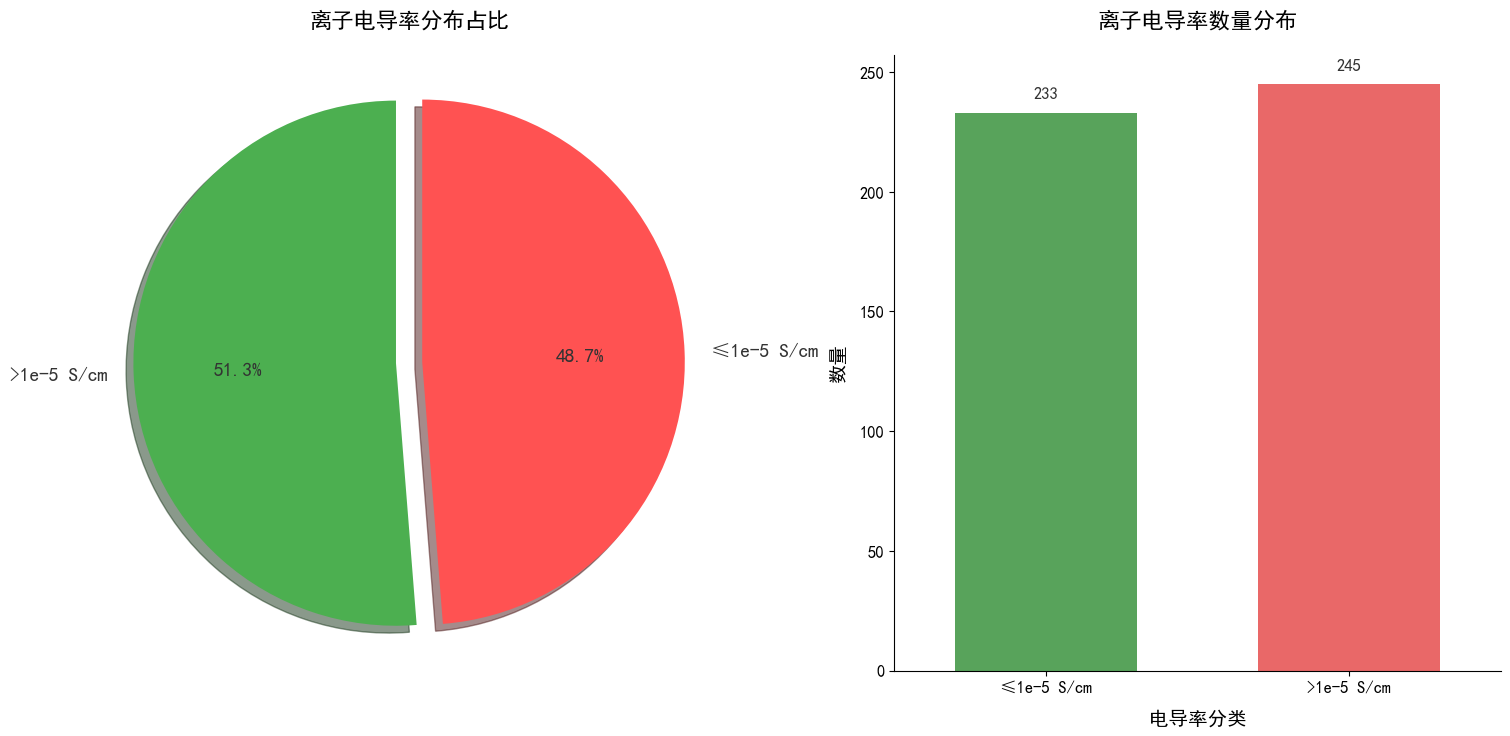

In [7]:
# 创建画布和子图，调整间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 调整子图间距

# 定义配色方案（柔和且对比明显）
colors = ['#4CAF50', '#FF5252']  # 绿色和红色（适合二分类对比）

# ======================
# 关键修复：先把文本转成数字（解决TypeError）
# ======================
# 1. 文本列 → 数字列（忽略无法转换的错误，空值用NaN填充）
train['conductivity_numeric'] = pd.to_numeric(
    train['High Ionic conductivity'], 
    errors='coerce'  # 遇到非数字值时转成NaN
)

# 2. 删除空值（避免后续报错）
train_clean = train.dropna(subset=['conductivity_numeric']).copy()

# 3. 新增电导率分类列（阈值 1e-5 S/cm）
train_clean['conductivity_class'] = train_clean['conductivity_numeric'].apply(
    lambda x: '>1e-5 S/cm' if x > 1e-5 else '≤1e-5 S/cm'
)

# ======================
# 饼图优化（用清洗后的数据）
# ======================
train_clean['conductivity_class'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    colors=colors,
    startangle=90,
    textprops={'fontsize': 14, 'color': '#333333'}
)
ax[0].set_title('离子电导率分布占比', fontsize=16, pad=20, fontweight='bold')
ax[0].set_ylabel('')
ax[0].axis('equal')

# ======================
# 柱状图优化（用清洗后的数据）
# ======================
sns.countplot(
    x='conductivity_class',
    data=train_clean,
    ax=ax[1],
    palette=colors,
    width=0.6
)
ax[1].set_title('离子电导率数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('电导率分类', fontsize=14, labelpad=10)
ax[1].set_ylabel('数量', fontsize=14, labelpad=10)

# 为柱状图添加数值标签
for p in ax[1].patches:
    height = p.get_height()
    ax[1].text(
        p.get_x() + p.get_width() / 2.,
        height + 5,
        f'{int(height)}',  # 转成整数，避免小数
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 美化坐标轴刻度
ax[1].tick_params(axis='both', which='major', labelsize=12)

# 去除顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

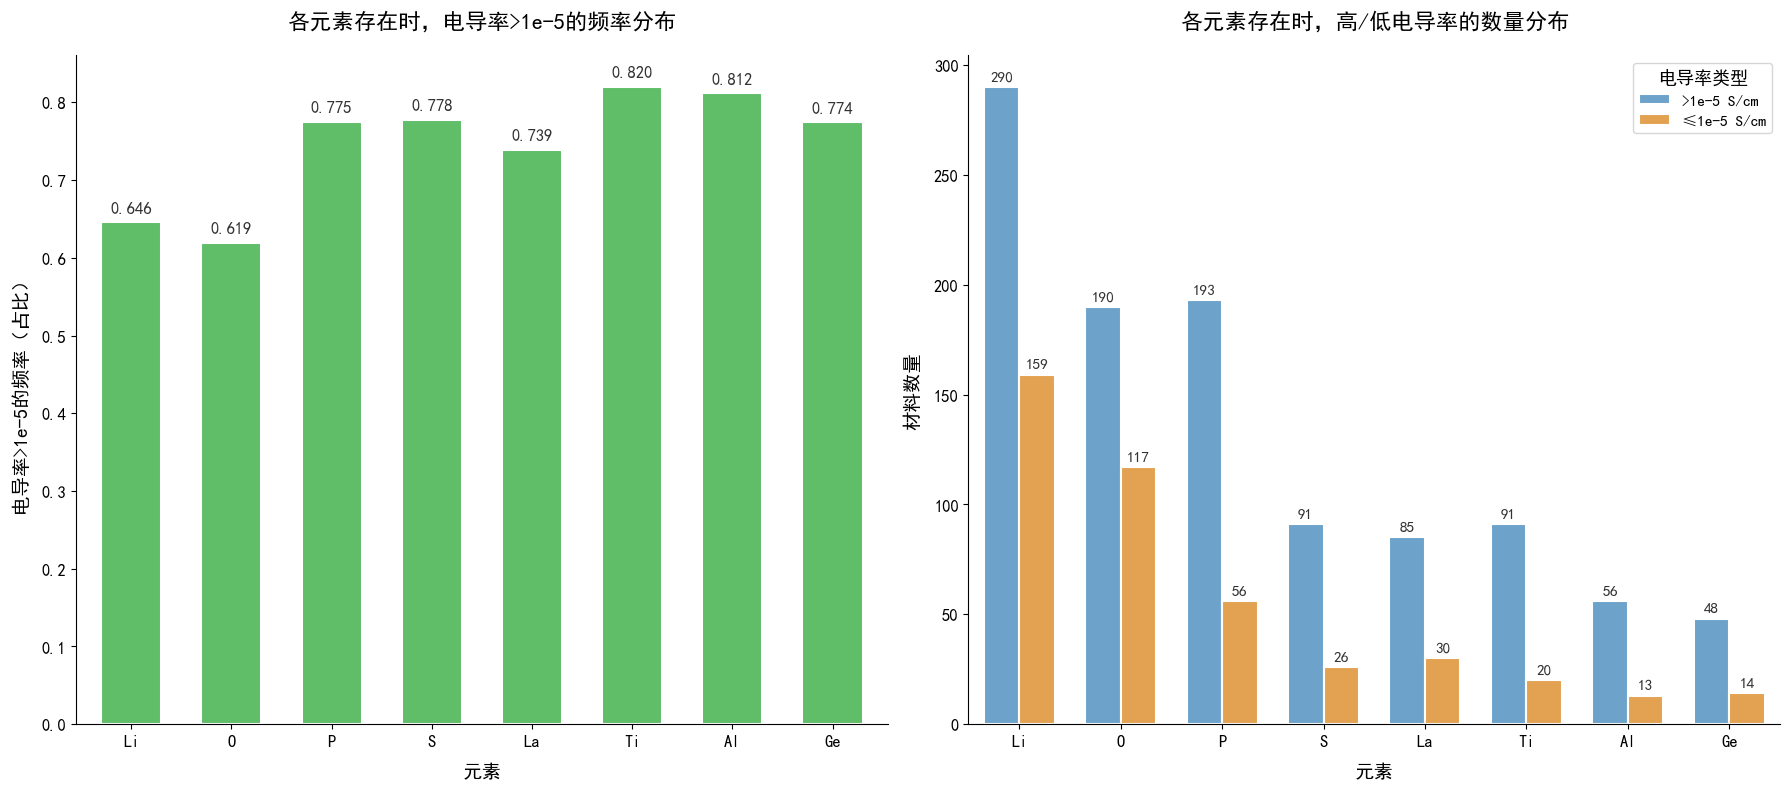

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# ======================
# 第一步：数据准备 + 仅保留“元素存在”的标签化
# ======================
# 1. 关键列定义（成分列=Reduced Composition，电导率列不变）
comp_col = 'Reduced Composition'
cond_col = 'Ionic conductivity (S cm-1)'
threshold = 1e-5

# 2. 电导率预处理（文本转数字+高/低分类）
train['conductivity_numeric'] = pd.to_numeric(train[cond_col], errors='coerce')
train['high_conductivity'] = (train['conductivity_numeric'] > threshold).astype(int)  # 1=>1e-5，0=≤1e-5
train_clean = train.dropna(subset=['conductivity_numeric', comp_col]).copy()

# 3. 提取元素并筛选高频元素（取前8个，避免图拥挤）
def extract_elements(formula):
    elements = re.findall(r'[A-Z][a-z]*', str(formula))
    return list(set(elements))

all_elements = []
for formula in train_clean[comp_col]:
    all_elements.extend(extract_elements(formula))
top_elements = [elem for elem, _ in Counter(all_elements).most_common(8)]  # 仅保留高频元素

# 4. 仅统计“有该元素”的材料数据（核心简化：删除无元素场景）
elem_stats = []
for elem in top_elements:
    # 只筛选“包含当前元素”的材料
    has_elem_data = train_clean[train_clean[comp_col].apply(lambda x: elem in extract_elements(x))]
    if len(has_elem_data) == 0:
        continue  # 跳过无数据的元素
    
    # 统计“有该元素”时的高/低电导率数量和频率
    high_cond_count = has_elem_data['high_conductivity'].sum()
    low_cond_count = len(has_elem_data) - high_cond_count
    high_cond_freq = high_cond_count / len(has_elem_data)  # 电导率>1e-5的频率
    
    elem_stats.append({
        '元素': elem,  # 仅显示元素名（无“有/无”区分）
        '电导率>1e-5频率': high_cond_freq,
        '高电导率数量': high_cond_count,
        '低电导率数量': low_cond_count,
        '总材料数量': len(has_elem_data)
    })

elem_stats_df = pd.DataFrame(elem_stats)

# ======================
# 第二步：复刻原代码风格绘图（双图布局，仅展示“元素存在”场景）
# ======================
# 创建画布，调整子图间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.25)

# 定义统一配色（沿用原代码风格，适配单一场景）
bar_colors = ['#5DA5DA', '#FAA43A']  # 蓝色=高电导率，橙色=低电导率
mean_color = '#60BD68'  # 频率图用绿色

# ----------------------
# 左侧：各元素存在时，电导率>1e-5的频率分布图
# ----------------------
elem_freq_groups = elem_stats_df.set_index('元素')['电导率>1e-5频率']
elem_freq_groups.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.6,
    edgecolor='white',
    linewidth=1.5
)
# 标题删除括号内内容，x轴标签删除括号内容
ax[0].set_title('各元素存在时，电导率>1e-5的频率分布', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('元素', fontsize=14, labelpad=10)  # 移除括号内“仅统计存在该元素的材料”
ax[0].set_ylabel('电导率>1e-5的频率（占比）', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=0)  # 元素名水平显示，更清晰
ax[0].tick_params(axis='y', labelsize=12)

# 为频率图添加数值标签（保留3位小数）
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.01,
        f'{p.get_height():.3f}',
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 去除左侧图顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# ----------------------
# 右侧：各元素存在时，高/低电导率的数量分布图
# ----------------------
# 重塑数据为“元素-电导率类型-数量”格式（仅保留元素存在场景）
count_data = []
for _, row in elem_stats_df.iterrows():
    count_data.append({'元素': row['元素'], '电导率类型': '>1e-5 S/cm', '数量': row['高电导率数量']})
    count_data.append({'元素': row['元素'], '电导率类型': '≤1e-5 S/cm', '数量': row['低电导率数量']})
count_df = pd.DataFrame(count_data)

# 分组数量图
sns.barplot(
    x='元素',
    y='数量',
    hue='电导率类型',
    data=count_df,
    ax=ax[1],
    palette=bar_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.5
)
# 标题保留无括号内容，x轴标签删除括号内容
ax[1].set_title('各元素存在时，高/低电导率的数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('元素', fontsize=14, labelpad=10)  # 移除括号内“仅统计存在该元素的材料”
ax[1].set_ylabel('材料数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=0)
ax[1].tick_params(axis='y', labelsize=12)

# 为数量图添加数值标签（整数显示）
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 2,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, color='#333333'
        )

# 优化右侧图图例
ax[1].legend(title='电导率类型', title_fontsize=13, fontsize=11, loc='upper right')
# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整，避免标签截断
plt.tight_layout()
plt.show()


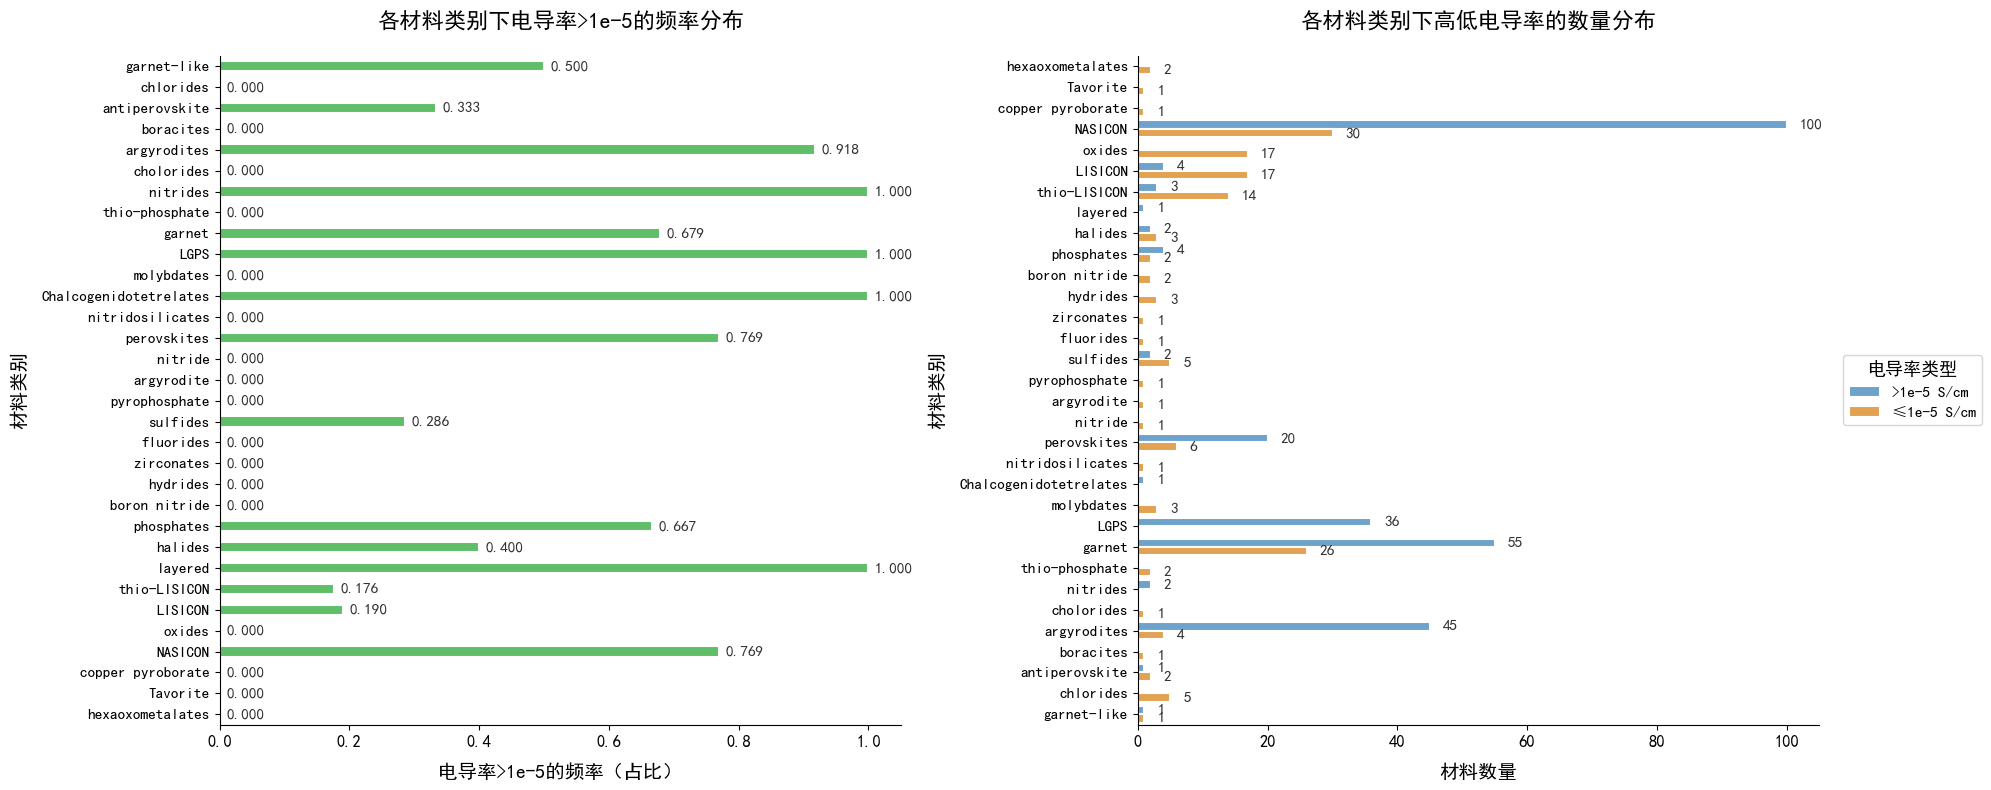

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 第一步：数据准备（沿用Family列，仅修改显示表述）
# ======================
material_type_col = 'Family'  # 数据列仍为Family，仅显示时不体现
cond_col = 'Ionic conductivity (S cm-1)'
threshold = 1e-5

# 确保电导率分类已存在
if 'conductivity_numeric' not in train.columns:
    train['conductivity_numeric'] = pd.to_numeric(train[cond_col], errors='coerce')
if 'high_conductivity' not in train.columns:
    train['high_conductivity'] = (train['conductivity_numeric'] > threshold).astype(int)

# 数据清洗
train_clean = train.dropna(subset=[material_type_col, 'conductivity_numeric']).copy()

# 统计各材料类别的电导率指标（数据列用Family，显示列名改为“材料类别”）
material_stats = []
for category in train_clean[material_type_col].unique():
    category_data = train_clean[train_clean[material_type_col] == category]
    total = len(category_data)
    high_cond_count = category_data['high_conductivity'].sum()
    low_cond_count = total - high_cond_count
    high_cond_freq = high_cond_count / total if total > 0 else 0
    
    material_stats.append({
        '材料类别': category,  # 显示用列名：材料类别（不包含Family）
        '电导率>1e-5频率': high_cond_freq,
        '高电导率数量': high_cond_count,
        '低电导率数量': low_cond_count,
        '总数量': total
    })

material_stats_df = pd.DataFrame(material_stats)

# ======================
# 第二步：横向柱状图绘制（标题、标签均无Family）
# ======================
# 创建画布，调整子图间距
f, ax = plt.subplots(1, 2, figsize=(20, 8))
plt.subplots_adjust(wspace=0.3)

# 统一配色（沿用原风格）
bar_colors = ['#5DA5DA', '#FAA43A']  # 蓝色=高电导率，橙色=低电导率
mean_color = '#60BD68'  # 频率图绿色

# ----------------------
# 左侧：横向频率图（标题无Family）
# ----------------------
material_freq_groups = material_stats_df.set_index('材料类别')['电导率>1e-5频率']
material_freq_groups.plot.barh(
    ax=ax[0],
    color=mean_color,
    edgecolor='white',
    linewidth=1.5
)
# 标题修改：去除Family，改为“材料类别”
ax[0].set_title('各材料类别下电导率>1e-5的频率分布', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('电导率>1e-5的频率（占比）', fontsize=14, labelpad=10)
ax[0].set_ylabel('材料类别', fontsize=14, labelpad=10)  # y轴标签无Family
ax[0].tick_params(axis='y', labelsize=11)
ax[0].tick_params(axis='x', labelsize=12)

# 横向图数值标签
for i, p in enumerate(ax[0].patches):
    width = p.get_width()
    ax[0].text(
        width + 0.01,
        p.get_y() + p.get_height()/2,
        f'{width:.3f}',
        ha='left', va='center', fontsize=11, color='#333333'
    )

# 去除顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# ----------------------
# 右侧：横向数量图（标题、标签均无Family）
# ----------------------
# 重塑数据（显示用列名：材料类别）
count_data = []
for _, row in material_stats_df.iterrows():
    count_data.append({'材料类别': row['材料类别'], '电导率类型': '>1e-5 S/cm', '数量': row['高电导率数量']})
    count_data.append({'材料类别': row['材料类别'], '电导率类型': '≤1e-5 S/cm', '数量': row['低电导率数量']})
count_df = pd.DataFrame(count_data)

# 横向数量图
sns.barplot(
    y='材料类别',  # y轴标签无Family
    x='数量',
    hue='电导率类型',
    data=count_df,
    ax=ax[1],
    palette=bar_colors,
    edgecolor='white',
    linewidth=1.5
)
# 标题修改：去除Family，改为“材料类别”
ax[1].set_title('各材料类别下高低电导率的数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('材料数量', fontsize=14, labelpad=10)
ax[1].set_ylabel('材料类别', fontsize=14, labelpad=10)  # y轴标签无Family
ax[1].tick_params(axis='y', labelsize=11)
ax[1].tick_params(axis='x', labelsize=12)

# 横向数量图数值标签
for p in ax[1].patches:
    width = p.get_width()
    if width > 0:
        ax[1].text(
            width + 2,
            p.get_y() + p.get_height()/2,
            f'{int(width)}',
            ha='left', va='center', fontsize=11, color='#333333'
        )

# 优化图例
ax[1].legend(title='电导率类型', title_fontsize=13, fontsize=11, loc='center right', bbox_to_anchor=(1.25, 0.5))

# 去除顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整
plt.tight_layout()
plt.show()

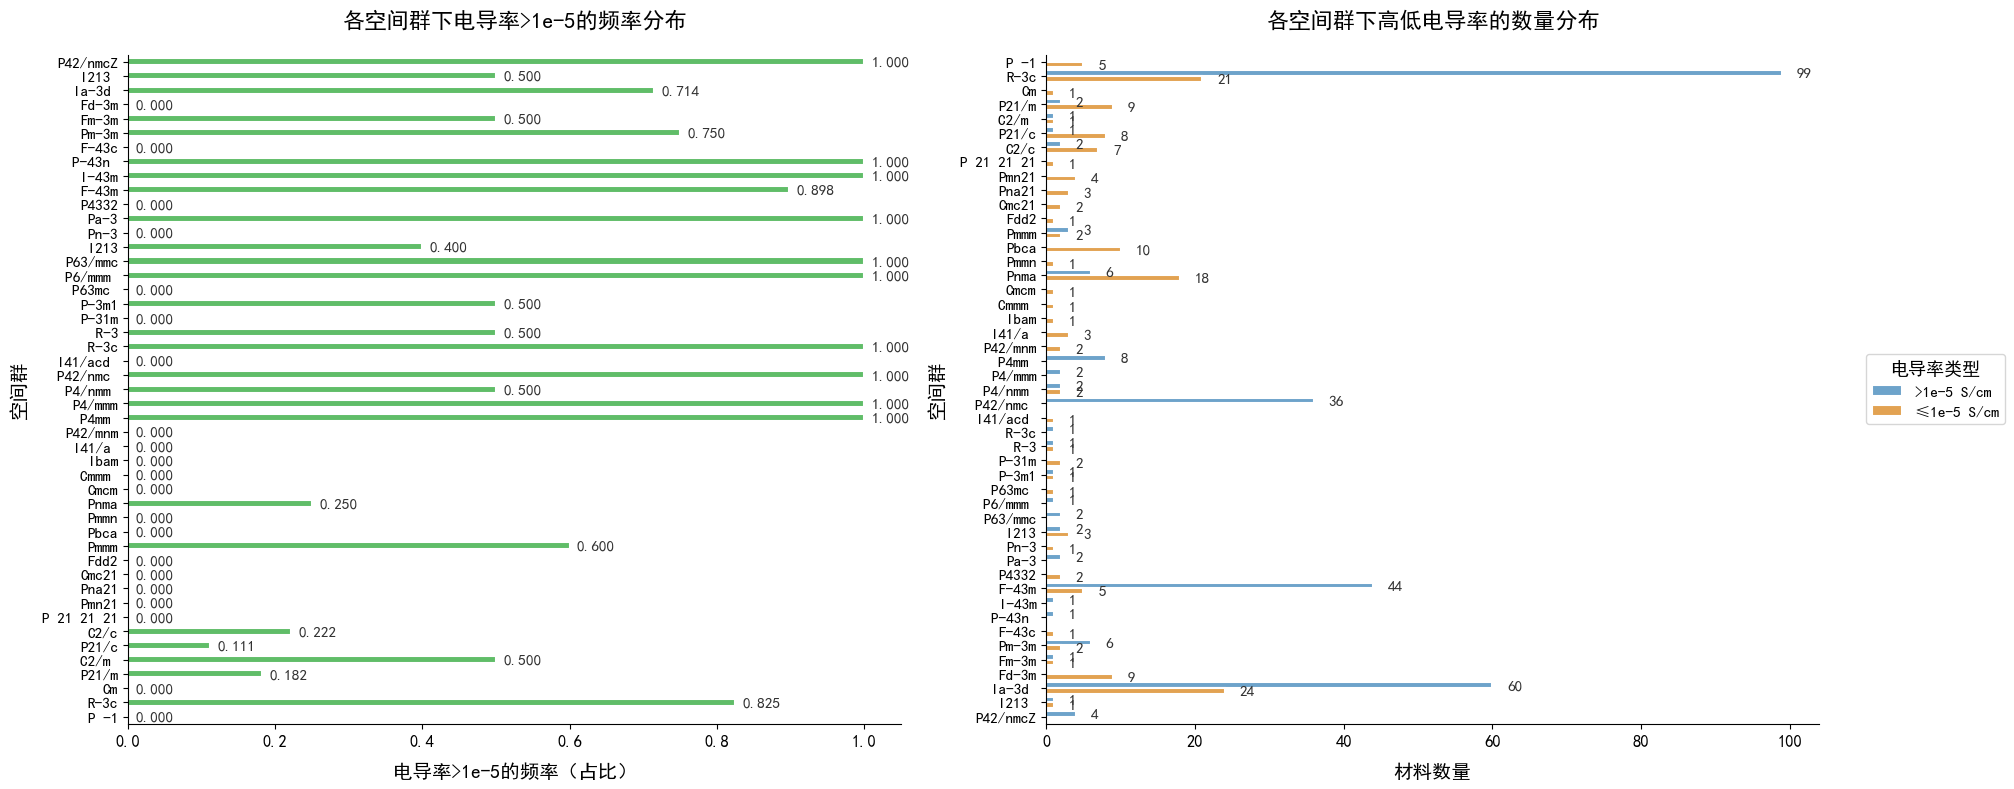

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 第一步：数据准备（适配Space group列）
# ======================
# 1. 关键列定义（核心修改：空间群列名改为Space group，匹配你的数据）
space_group_col = 'Space group'  # 修正为Space group（首字母大写），确认数据列名一致！
cond_col = 'Ionic conductivity (S cm-1)'
threshold = 1e-5

# 2. 确保电导率分类已存在（若之前未运行，自动补充）
if 'conductivity_numeric' not in train.columns:
    train['conductivity_numeric'] = pd.to_numeric(train[cond_col], errors='coerce')
if 'high_conductivity' not in train.columns:
    train['high_conductivity'] = (train['conductivity_numeric'] > threshold).astype(int)

# 3. 数据清洗（保留有Space group和有效电导率的行）
train_clean = train.dropna(subset=[space_group_col, 'conductivity_numeric']).copy()

# 4. 统计各Space group的电导率指标（频率+数量）
space_group_stats = []
for sg in train_clean[space_group_col].unique():
    sg_data = train_clean[train_clean[space_group_col] == sg]
    total = len(sg_data)
    high_cond_count = sg_data['high_conductivity'].sum()
    low_cond_count = total - high_cond_count
    high_cond_freq = high_cond_count / total if total > 0 else 0  # 高电导率频率（占比）
    
    space_group_stats.append({
        '空间群': sg,
        '电导率>1e-5频率': high_cond_freq,
        '高电导率数量': high_cond_count,
        '低电导率数量': low_cond_count,
        '总数量': total
    })

space_group_stats_df = pd.DataFrame(space_group_stats)

# ======================
# 第二步：横向柱状图绘制（简洁标题+无冗余括号）
# ======================
# 创建画布（横向布局，加宽画布适配空间群名称）
f, ax = plt.subplots(1, 2, figsize=(20, 8))
plt.subplots_adjust(wspace=0.3)

# 统一配色（沿用之前的专业风格）
bar_colors = ['#5DA5DA', '#FAA43A']  # 蓝色=高电导率，橙色=低电导率
mean_color = '#60BD68'  # 频率图用绿色

# ----------------------
# 左侧：横向频率图（Space group-高电导率频率）
# ----------------------
sg_freq_groups = space_group_stats_df.set_index('空间群')['电导率>1e-5频率']
sg_freq_groups.plot.barh(
    ax=ax[0],
    color=mean_color,
    edgecolor='white',
    linewidth=1.5
)
# 简洁标题（无括号、无冗余内容）
ax[0].set_title('各空间群下电导率>1e-5的频率分布', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('电导率>1e-5的频率（占比）', fontsize=14, labelpad=10)
ax[0].set_ylabel('空间群', fontsize=14, labelpad=10)
ax[0].tick_params(axis='y', labelsize=11)
ax[0].tick_params(axis='x', labelsize=12)

# 横向频率图数值标签（保留3位小数）
for p in ax[0].patches:
    width = p.get_width()
    ax[0].text(
        width + 0.01,
        p.get_y() + p.get_height()/2,
        f'{width:.3f}',
        ha='left', va='center', fontsize=11, color='#333333'
    )

# 去除顶部/右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# ----------------------
# 右侧：横向数量图（Space group-高低电导率数量）
# ----------------------
# 重塑数据适配绘图
count_data = []
for _, row in space_group_stats_df.iterrows():
    count_data.append({'空间群': row['空间群'], '电导率类型': '>1e-5 S/cm', '数量': row['高电导率数量']})
    count_data.append({'空间群': row['空间群'], '电导率类型': '≤1e-5 S/cm', '数量': row['低电导率数量']})
count_df = pd.DataFrame(count_data)

# 横向数量图
sns.barplot(
    y='空间群',
    x='数量',
    hue='电导率类型',
    data=count_df,
    ax=ax[1],
    palette=bar_colors,
    edgecolor='white',
    linewidth=1.5
)
# 简洁标题（无括号、无冗余内容）
ax[1].set_title('各空间群下高低电导率的数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('材料数量', fontsize=14, labelpad=10)
ax[1].set_ylabel('空间群', fontsize=14, labelpad=10)
ax[1].tick_params(axis='y', labelsize=11)
ax[1].tick_params(axis='x', labelsize=12)

# 横向数量图数值标签（仅显示非零值）
for p in ax[1].patches:
    width = p.get_width()
    if width > 0:
        ax[1].text(
            width + 2,
            p.get_y() + p.get_height()/2,
            f'{int(width)}',
            ha='left', va='center', fontsize=11, color='#333333'
        )

# 优化图例位置（横向图适配右侧居中）
ax[1].legend(title='电导率类型', title_fontsize=13, fontsize=11, loc='center right', bbox_to_anchor=(1.25, 0.5))

# 去除顶部/右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整，避免标签截断
plt.tight_layout()
plt.show()

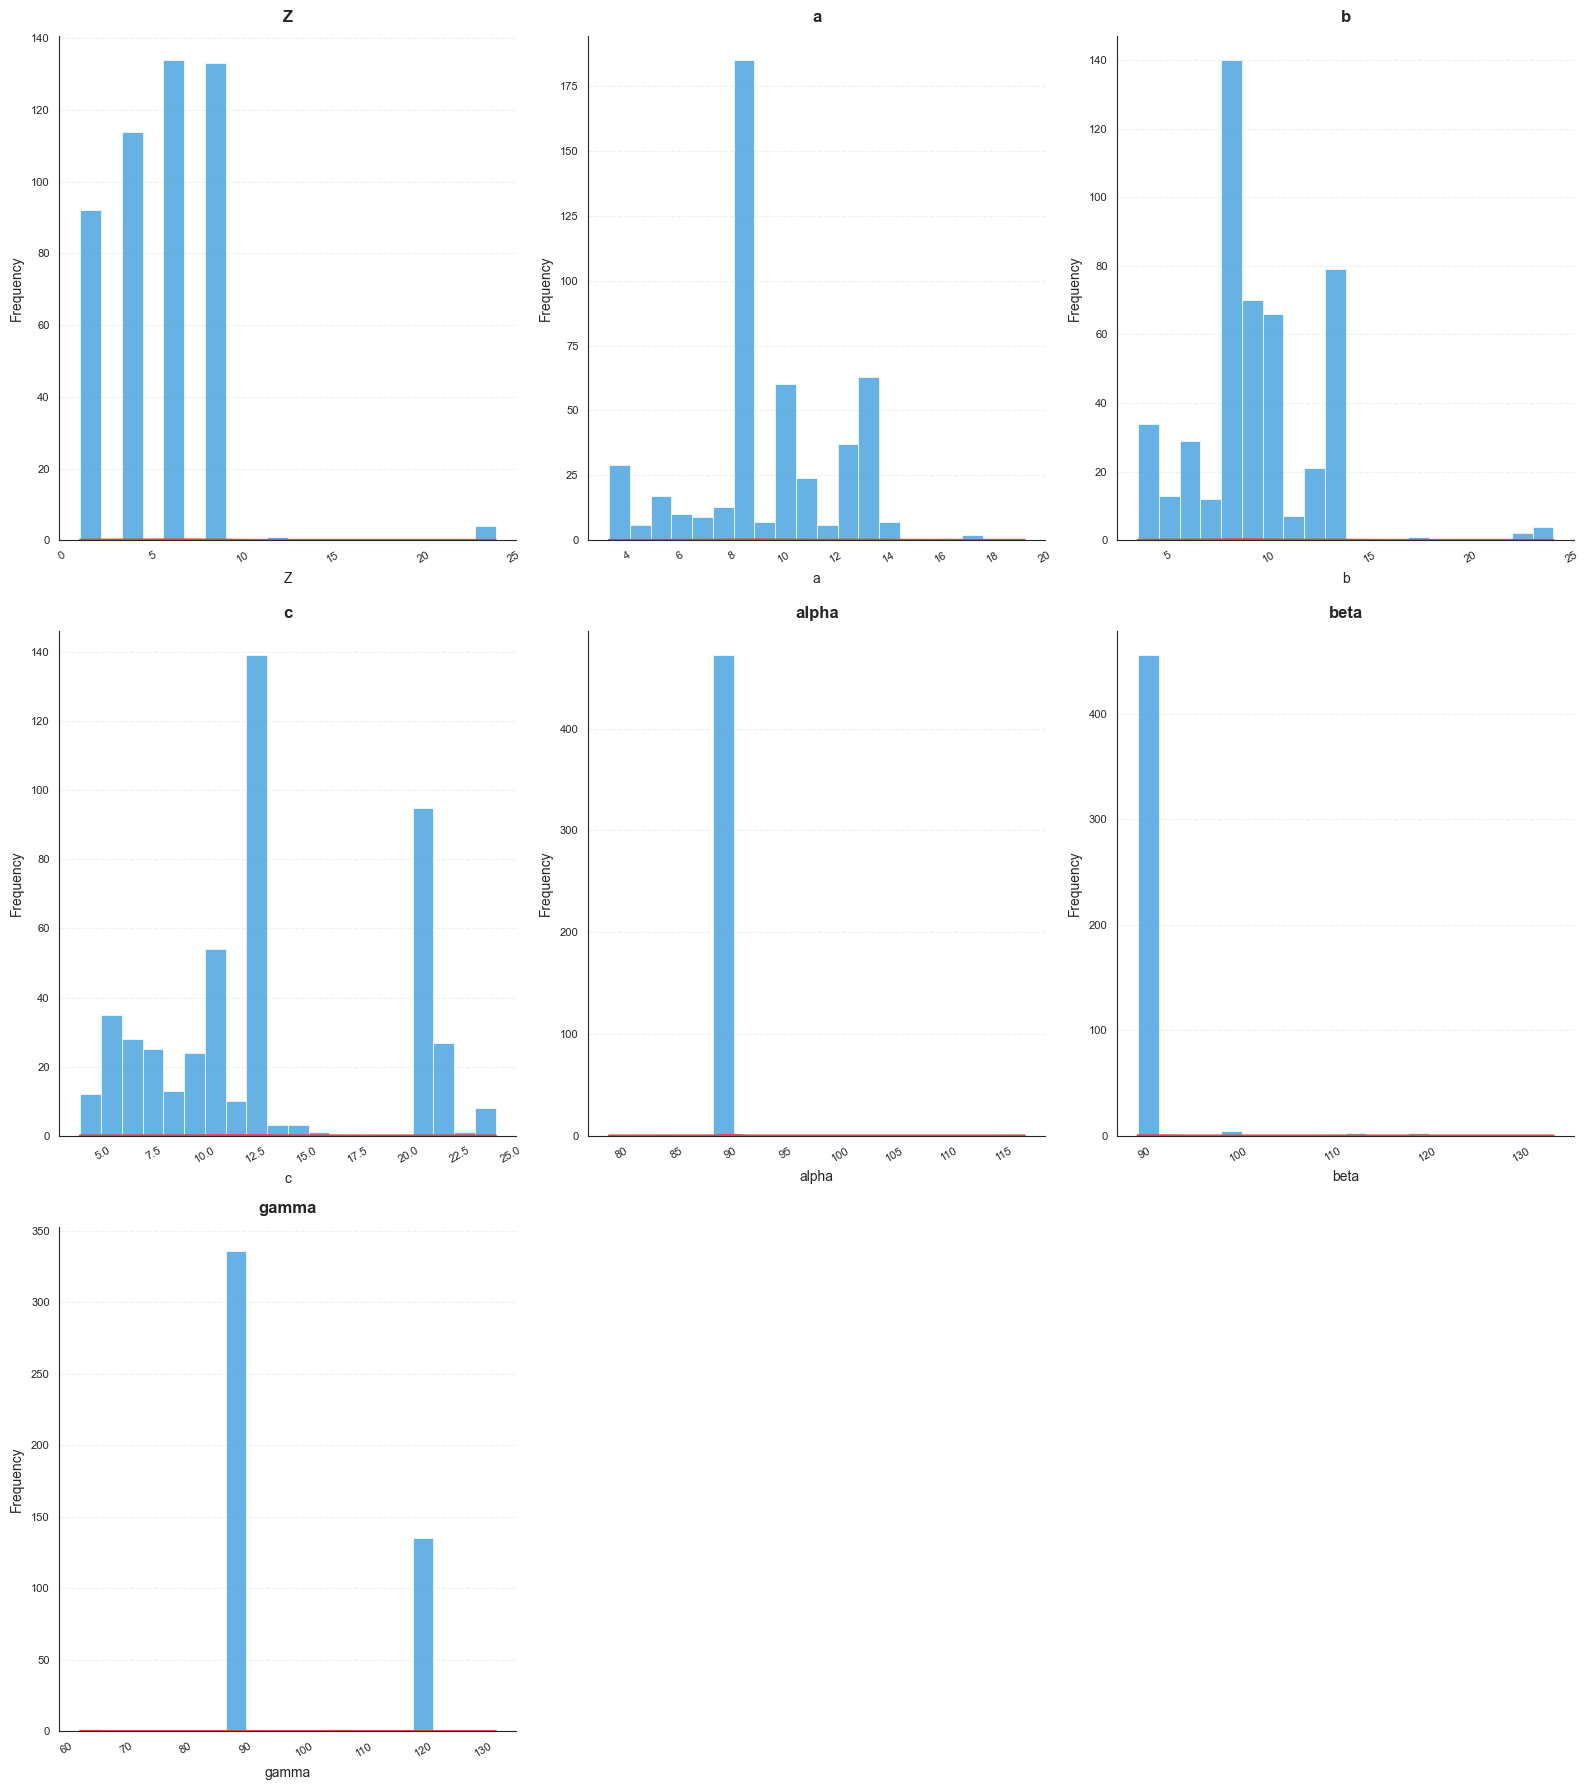

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ======================
# 第一步：样式配置（完全复用你的参数）
# ======================
sns.set_style("white")
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# 定义晶格参数列表（Z/a/b/c/alpha/beta/gamma）
LATTICE_FEATURES = ['Z', 'a', 'b', 'c', 'alpha', 'beta', 'gamma']

# 计算子图布局（3行3列，适配7个参数，剩余子图隐藏）
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()  # 展平为一维数组，方便遍历

# ======================
# 第二步：绘制每个晶格参数的频数直方图（彻底修复参数兼容问题）
# ======================
for i, feature in enumerate(LATTICE_FEATURES):
    ax = axes[i]
    
    # 步骤1：单独绘制直方图（仅传递matplotlib支持的参数）
    sns.histplot(
        data=train,  # 替换为你的实际数据框
        x=feature, 
        bins=20, 
        kde=False,  # 先关闭KDE，单独绘制
        ax=ax,
        color='#3498db',  # 直方图主体颜色（蓝色）
        edgecolor='white',
        linewidth=0.5
    )
    
    # 步骤2：单独绘制KDE曲线（避免参数冲突）
    # 提取特征数据并去除缺失值
    feature_data = train[feature].dropna()
    if len(feature_data) > 0:  # 避免空数据报错
        sns.kdeplot(
            x=feature_data,
            ax=ax,
            color='#e74c3c',  # 核密度曲线颜色（红色）
            linewidth=2,
            cut=0  # KDE曲线截断参数
        )
    
    # 设置标题和标签（适配你的样式）
    ax.set_title(f'{feature}', pad=10, fontweight='bold')
    ax.set_xlabel(feature, labelpad=5)
    ax.set_ylabel('Frequency', labelpad=5)
    
    # 美化坐标轴（隐藏顶部/右侧边框）
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30)  # x轴标签旋转30度
    
    # 添加网格线（仅y轴，半透明虚线）
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)  # 网格线在直方图下方

# ======================
# 第三步：隐藏多余的子图（3行3列共9个，仅用7个）
# ======================
for j in range(len(LATTICE_FEATURES), len(axes)):
    axes[j].set_visible(False)

# 调整子图间距，避免标题/标签重叠
plt.tight_layout()
plt.show()

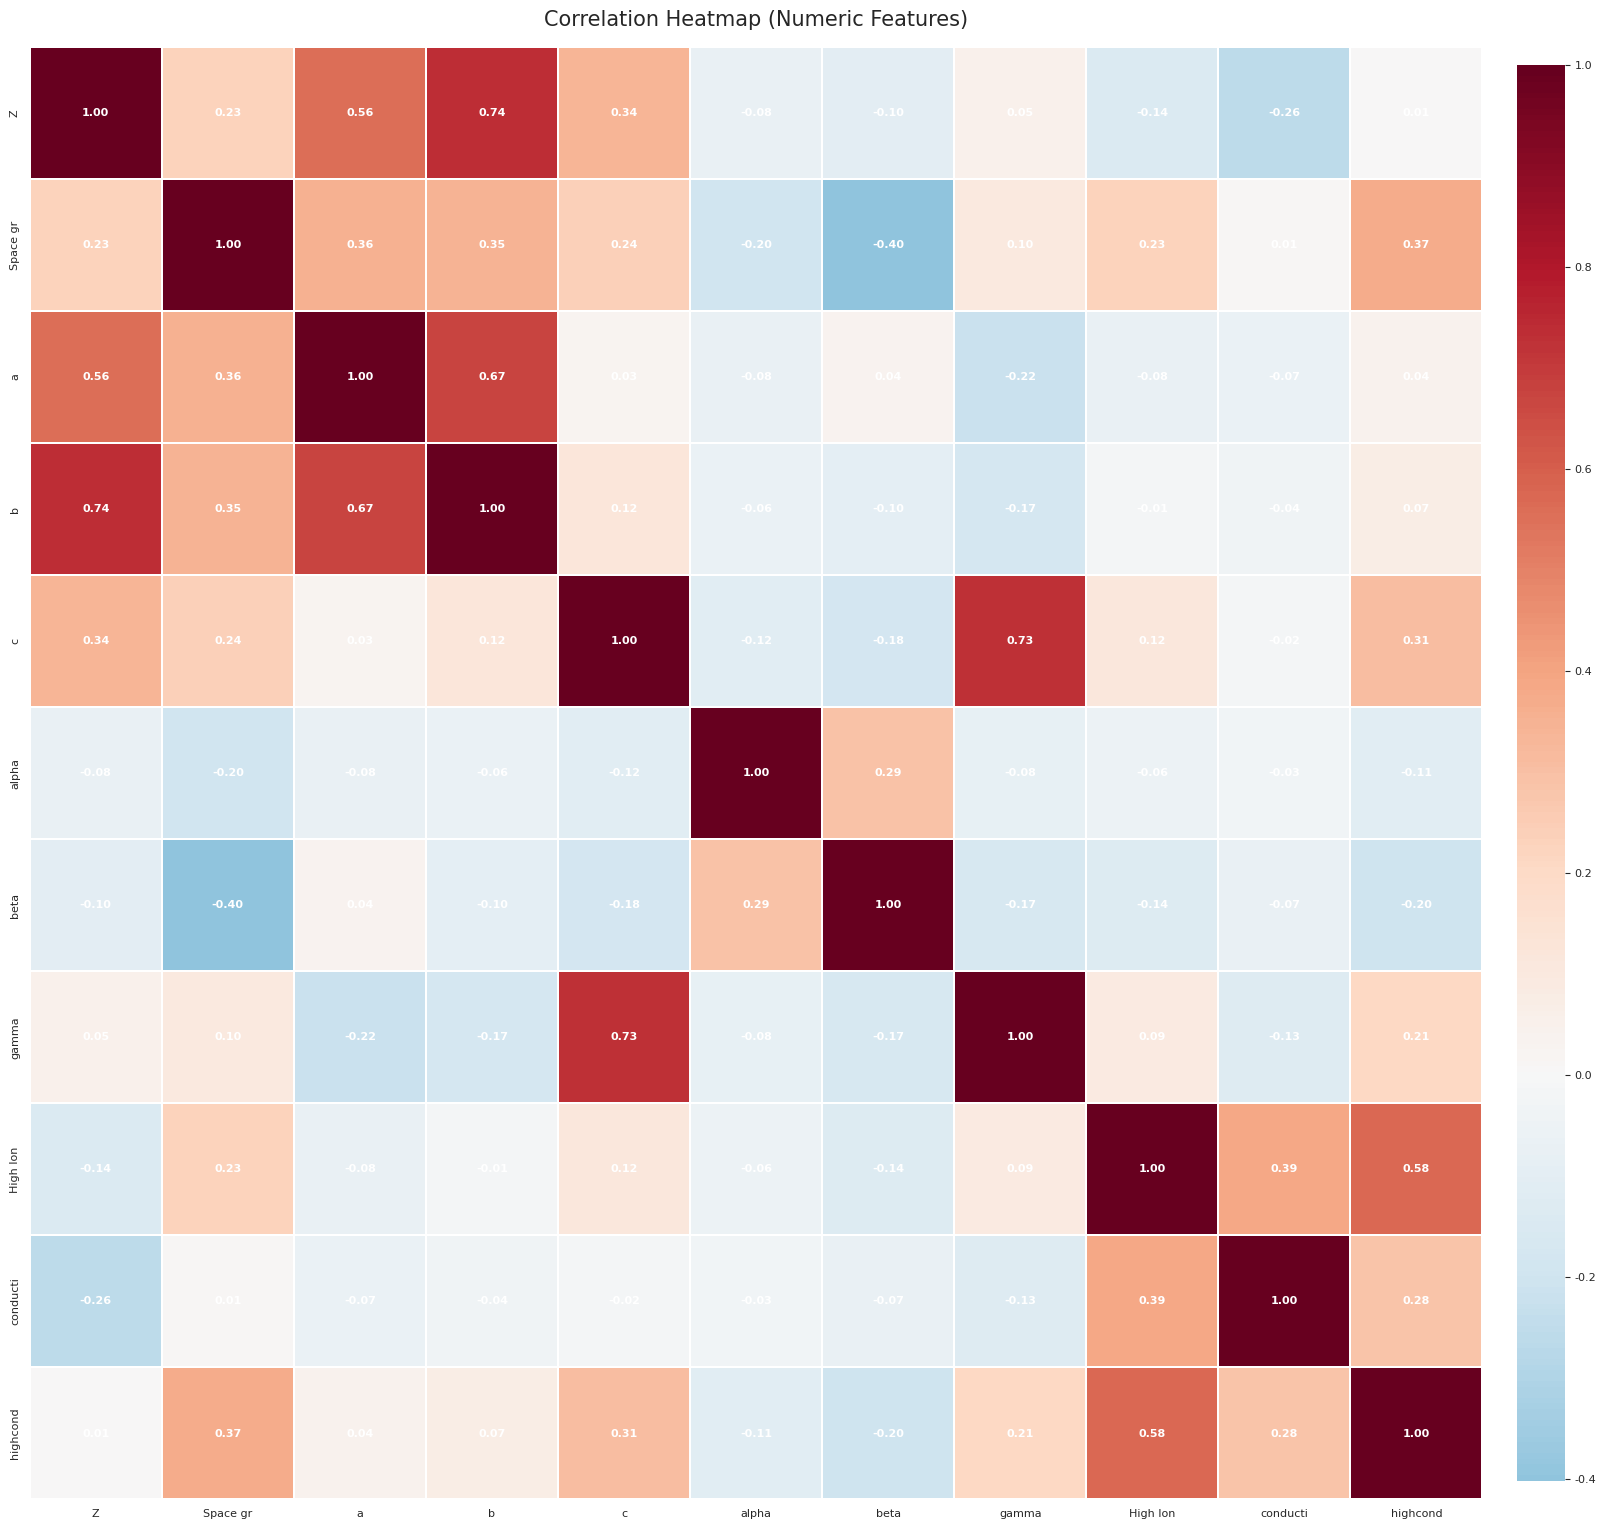

In [12]:
# ------------------------------------------------------------------
# 最终版：大号白色数字+紧凑方格+红蓝配色 正方形热力图
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook 内显示图片
%matplotlib inline

# ===================== 核心样式配置 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.linewidth'] = 0  # 隐藏边框
plt.rcParams['xtick.labelsize'] = 8  # 轴标签字号同步放大，更协调
plt.rcParams['ytick.labelsize'] = 8

# 18尺寸正方形画布（适配8号数字，避免重叠）
size = 18  
fig, ax = plt.subplots(figsize=(size, size))

# 筛选数值特征并计算相关系数
numeric_df = train.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# ===================== 绘制大号白色数字热力图 =====================
sns.heatmap(
    corr,
    ax=ax,
    annot=True,        # 开启数字注释
    annot_kws={
        'size': 8,      # 按要求调至8号字（核心修改）
        'weight': 'bold',# 加粗数字，更醒目
        'color': 'white' # 按要求改为白色，红/蓝背景上对比极强
    },
    fmt='.2f',         # 数字保留2位小数
    cmap='RdBu_r',     # 红蓝配色（匹配目标效果）
    center=0,          # 0值为白色
    square=True,       # 强制每个格子正方形
    linewidths=0.1,    # 极细分割线，区分格子边界
    cbar=True,         # 显示右侧色条
    cbar_kws={
        "shrink": 0.8,  # 色条适配画布
        "aspect": 30,   # 色条细长
        "pad": 0.02     # 色条与热力图间距
    },
    # 特征名缩写（保持紧凑）
    xticklabels=[label.replace('wd_', '').replace('_', '')[:8] for label in corr.columns],
    yticklabels=[label.replace('wd_', '').replace('_', '')[:8] for label in corr.index]
)

# 设置标题（字号同步放大）
plt.title('Correlation Heatmap (Numeric Features)', fontsize=15, pad=15)

# 调整布局（避免数字/标签被截断）
plt.tight_layout()

# 显示 + 保存超高清图（白色数字无模糊）
plt.show()
fig.savefig('fig_heatmap_final.png', dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.close()

# <a id='toc5_'></a>[工具函数](#toc0_)

In [13]:
def f1_best_threshold(y_true, y_prob):
    """返回最大化 F1 的阈值与对应 F1"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]



# <a id='toc6_'></a>[数据预处理](#toc0_)


功能：处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备

In [14]:
class DataPreprocessing:
    def __init__(self):
        pass

    def fit(self, X):
        pass

    def transform(self, X):
        """对数据进行清洗转换：处理异常值、填充缺失值、添加标记列"""
        # 复制输入数据，避免修改原始数据
        X = X.copy()
        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

 **关键新特征构建**  
   计算晶格体积特征，挖掘数据中隐藏的指标关联与组合效应，丰富特征维度。

In [15]:
class FeatureGenerator:
    """特征生成器类，用于对输入数据进行特征工程处理，生成模型所需的特征"""
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据
            
        返回:
            pandas.DataFrame，处理后的特征数据
        """
        # 复制输入数据，避免修改原始数据
        df_features = X.copy()
        epsilon = 1e-6  # 防止除以零
    
        # ==========================================
        # 1. 晶格参数特征：计算晶格体积（基于a/b/c/alpha/beta/gamma）
        df_features['lattice_volume'] = df_features['a'] * df_features['b'] * df_features['c'] * np.sqrt(1 - (np.cos(np.radians(df_features['alpha'])))**2 - (np.cos(np.radians(df_features['beta'])))**2 - (np.cos(np.radians(df_features['gamma'])))**2 + 2 * np.cos(np.radians(df_features['alpha'])) * np.cos(np.radians(df_features['beta'])) * np.cos(np.radians(df_features['gamma'])))
        # ==========================================
        
        # 返回处理后的特征数据
        return df_features


In [16]:
# Define the label and description columns based on the dataset
LABEL = 'High Ionic conductivity'
LABEL_DESC = 'Ionic conductivity (S cm-1)'

train_X, test_X, train_y, test_y = train_test_split(
    train.drop(columns=[LABEL, LABEL_DESC]), # drop LABEL LABEL_DESC
    train[LABEL],
    test_size=0.2, random_state=42,
)

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)

In [17]:
def clean_feature_names(columns):
    new_columns = []
    for col in columns:
        # 1. 替换特殊字符 (括号, &, %, 逗号) 为下划线
        new_col = re.sub(r'[(),&%\s:-]+', '_', col)
        # 2. 去除首尾可能的下划线
        new_col = new_col.strip('_')
        new_columns.append(new_col)

    return new_columns

In [18]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# ===================== 第一步：数据类型清洗（核心！先解决列类型混乱问题） =====================
def clean_column_types(df):
    """
    清洗列类型：
    1. 尝试将所有疑似数值列转为float（失败则保留object）
    2. 区分纯数值列/纯字符串列
    """
    df_clean = df.copy()
    for col in df_clean.columns:
        # 跳过明显的类别列（如包含字母的列，可根据你的数据调整关键词）
        if any(keyword in col.lower() for keyword in ['formula', '化学式', 'material', 'name']):
            continue
        # 尝试转换为数值型（无法转换的保留原类型）
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='raise')
        except (ValueError, TypeError):
            continue
    return df_clean

# 清洗训练/测试集的列类型
train_fe_clean = clean_column_types(train_fe)
test_fe_clean = clean_column_types(test_fe)

# ===================== 第二步：精准划分列类型（避免自动划分的坑） =====================
# 1. 手动指定核心类别列（优先！避免误判）- 只保留实际存在的列
cat_cols_manual = [
    col for col in ['formula', '化学式', 'material', 'name'] 
    if col in train_fe_clean.columns
]  # 动态筛选实际存在的列，避免KeyError

# 2. 自动筛选剩余的纯数值列（排除手动类别列 + 确保dtype是数值）
num_cols = [
    c for c in train_fe_clean.columns 
    if c not in cat_cols_manual and pd.api.types.is_numeric_dtype(train_fe_clean[c])
]

# 3. 自动筛选剩余的纯类别列（仅保留object类型且非数值的列）
cat_cols_auto = [
    c for c in train_fe_clean.columns 
    if c not in cat_cols_manual and c not in num_cols and train_fe_clean[c].dtype == 'object'
]

# 最终列划分：手动类别列 + 自动类别列
cat_cols = cat_cols_manual + cat_cols_auto

# 打印列划分结果（调试用，确认无问题）
print("=== 列划分结果 ===")
print(f"数值列({len(num_cols)}): {num_cols[:5]}..." if len(num_cols)>5 else f"数值列: {num_cols}")
print(f"类别列({len(cat_cols)}): {cat_cols}")
print(f"实际DataFrame列名: {list(train_fe_clean.columns[:10])}...")  # 调试用，显示实际列名

# ===================== 第三步：重构预处理流水线（修复OneHotEncoder稀疏矩阵问题） =====================
def construct_process_pipeline(num_cols, cat_cols):
    transformers = []
    
    # 数值特征流水线：中位数填充 + 标准化（仅当存在数值列时）
    if len(num_cols) > 0:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, num_cols))
    
    # 类别特征流水线：众数填充 + 独热编码（关键：sparse_output=False，避免稀疏矩阵）（仅当存在类别列时）
    if len(cat_cols) > 0:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_transformer, cat_cols))
    
    # 列转换器：严格区分处理，丢弃未指定列（兜底）
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'  # 丢弃未划分的列，避免漏网之鱼
    )
    
    return preprocessor

# ===================== 第四步：辅助函数：清洗特征名 =====================
def clean_feature_names(feature_names):
    """清理特征名称中的特殊符号"""
    return [
        name.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '_').replace('=', '')
        for name in feature_names
    ]

# ===================== 第五步：执行预处理（无报错） =====================
# 构建流水线
preprocess = construct_process_pipeline(num_cols, cat_cols)

# 拟合+转换训练集
X_train = preprocess.fit_transform(train_fe_clean)
columns = clean_feature_names(preprocess.get_feature_names_out())
X_train = pd.DataFrame(X_train, columns=columns)

# 转换测试集
X_test = preprocess.transform(test_fe_clean)
X_test = pd.DataFrame(X_test, columns=columns)

# ===================== 别名（供后续 OOF/SHAP 使用） =====================
X_full = X_train
y = train_y

# 验证结果
print("\n=== 预处理结果 ===")
print(f"训练集特征矩阵形状: {X_train.shape}")
print(f"测试集特征矩阵形状: {X_test.shape}")
print(f"前5个特征名: {columns[:5]}")

=== 列划分结果 ===
数值列(11): ['Z', 'Space group #', 'a', 'b', 'c']...
类别列(0): []
实际DataFrame列名: ['Reduced Composition', 'Z', 'True Composition', 'Space group', 'Space group #', 'a', 'b', 'c', 'alpha', 'beta']...

=== 预处理结果 ===
训练集特征矩阵形状: (382, 11)
测试集特征矩阵形状: (96, 11)
前5个特征名: ['num__Z', 'num__Space_group_#', 'num__a', 'num__b', 'num__c']


In [19]:
X_train.head()

,num__Z,num__Space_group_#,num__a,num__b,num__c,num__alpha,num__beta,num__gamma,num__conductivity_numeric,num__high_conductivity,num__lattice_volume
0,0.216532,0.158098,-0.285117,-0.228470,1.341192,-0.086519,-0.183139,1.508053,-0.279174,0.782186,0.219706
1,0.216532,0.158098,-0.267419,-0.212313,1.367033,-0.086519,-0.183139,1.508053,-0.307049,0.782186,0.254903
2,-0.499617,0.865891,0.254904,0.264544,-0.574896,-0.086519,-0.183139,-0.649440,-0.127127,0.782186,-0.246629
3,-0.499617,0.865891,0.245888,0.256313,-0.579173,-0.086519,-0.183139,-0.649440,0.292449,0.782186,-0.257217
4,-0.499617,-2.051948,-1.176234,-1.020002,-1.238066,-0.086519,7.003047,-0.649440,-0.380894,-1.278469,-1.397988


# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [20]:
# ------------------------------------------------------------------
# 小样本快速优化（用 3 折 & 700 样本）
# ------------------------------------------------------------------
train_size = 800 if X_train.shape[0] > 800 else int(X_train.shape[0] * 0.8)
sample_idx, _ = train_test_split(
    np.arange(X_train.shape[0]), stratify=train_y, train_size=train_size, random_state=42
)
X_sample, y_sample = X_train.iloc[sample_idx], train_y.iloc[sample_idx]

class_weight = len(train_y) / (2 * np.bincount(train_y))  # 类别权重
xgb_scale_weight = class_weight[1] / class_weight[0] if 'class_weight' in locals() else 1.0

In [21]:
# ===================== 1. 导入所有依赖 =====================

import pandas as pd
import numpy as np
import os
from matplotlib.pylab import rand
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# ===================== 2. 终极修复版bayes_opt函数（无任何多余参数） =====================
def bayes_opt(model, space, X, y, cv=3, n_iter=12, scoring='f1', rnd=42):
    """
    核心修复：
    1. 对CatBoost仅设置官方支持的参数，不添加任何自定义/无效参数
    2. 彻底不碰`verbose`参数，用`logging_level='Silent'`单一日志控制
    3. 单进程避免克隆时的参数冲突
    """
    if isinstance(model, cb.CatBoostClassifier):
        # 仅保留CatBoost官方明确支持的参数，不添加任何其他参数
        # 不设置 verbose，避免与 logging_level 冲突
        model.set_params(logging_level='Silent')

    # 单进程运行，避免多进程克隆参数问题
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=cv, scoring=scoring,
        random_state=rnd, n_jobs=1, verbose=0
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_

def bayes_opt_serial(model, space, X, y, n_iter=12):
    if isinstance(model, cb.CatBoostClassifier):
        model.set_params(logging_level='Silent')  # 仅设置官方参数
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=3, scoring='f1',
        random_state=42, n_jobs=1, verbose=0
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_

# ===================== 3. 参数空间（和你原代码一致） =====================
lgb_space = {'n_estimators': Integer(300,1500), 'learning_rate': Real(0.01,0.1,'log-uniform'),
             'num_leaves': Integer(20,100), 'max_depth': Integer(3,10),
             'min_child_samples': Integer(10,100), 'reg_alpha': Real(0.1,1.0), 'reg_lambda': Real(0.1,1.0)}
xgb_space = {'n_estimators': Integer(300,1500), 'learning_rate': Real(0.01,0.1,'log-uniform'),
             'max_depth': Integer(3,10), 'min_child_weight': Integer(1,10), 'gamma': Real(0,0.5),
             'subsample': Real(0.6,1.0), 'colsample_bytree': Real(0.6,1.0),
             'reg_alpha': Real(0.1,1.0), 'reg_lambda': Real(0.1,1.0)}
cat_space = {'iterations': Integer(300,1500), 'learning_rate': Real(0.01,0.1,'log-uniform'),
             'depth': Integer(3,10), 'l2_leaf_reg': Real(0.1,10.0)}
lr_space = {'C': Real(1e-3,1e2,'log-uniform'), 'penalty': Categorical(['l2']), 'solver': Categorical(['lbfgs','liblinear'])}
svc_space = {'C': Real(1e-3,1e2,'log-uniform'), 'kernel': Categorical(['linear','rbf']), 'gamma': Categorical(['scale','auto'])}
dt_space = {'max_depth': Integer(3,10), 'min_samples_split': Integer(2,20), 'min_samples_leaf': Integer(1,10), 'criterion': Categorical(['gini','entropy'])}
rf_space = {'n_estimators': Integer(100,500), 'max_depth': Integer(3,10), 'min_samples_split': Integer(2,20), 'max_features': Categorical(['sqrt','log2']), 'bootstrap': Categorical([True,False])}
gbdt_space = {'n_estimators': Integer(100,500), 'learning_rate': Real(0.01,0.2,'log-uniform'), 'max_depth': Integer(3,10), 'subsample': Real(0.6,1.0), 'min_samples_split': Integer(2,20)}
nb_space = {'var_smoothing': Real(1e-9,1e-5,'log-uniform')}
mlp_space = {'layer_idx': Categorical([0,1,2]), 'activation': Categorical(['tanh','relu']), 'alpha': Real(1e-5,1e-2,'log-uniform'), 'learning_rate_init': Real(1e-4,0.01,'log-uniform')}

# ===================== 4. 自定义MLP（和你原代码一致） =====================
class TunedMLP(MLPClassifier):
    def __init__(self, layer_idx=0, activation='relu', alpha=0.0001,
                 learning_rate_init=0.001, max_iter=1000, early_stopping=True,
                 random_state=None):
        self.layer_idx = layer_idx
        self.activation = activation
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.random_state = random_state
        self.layer_configs = [(50,), (100,), (50, 50)]
        super().__init__(
            hidden_layer_sizes=self.layer_configs[0],
            activation=activation, alpha=alpha,
            learning_rate_init=learning_rate_init, max_iter=max_iter,
            early_stopping=early_stopping, random_state=random_state
        )
    def fit(self, X, y):
        idx = int(self.layer_idx)
        idx = idx if 0 <= idx < 3 else 0
        self.hidden_layer_sizes = self.layer_configs[idx]
        return super().fit(X, y)

# ================= 基础模型 (Sklearn) =================
print('【逻辑回归 (LR) 贝叶斯优化】')
model = LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
lr_model, lr_best = bayes_opt(model, lr_space, X_sample, y_sample, n_iter=12)

print('【支持向量机 (SVM) 贝叶斯优化】')
# SVM 训练较慢，probability=True 会更慢，但在小样本(800)下可接受
model = SVC(probability=False, class_weight='balanced', random_state=42)
svm_model, svm_best = bayes_opt(model, svc_space, X_sample, y_sample, n_iter=1)

print('【决策树 (DT) 贝叶斯优化】')
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model, dt_best = bayes_opt(model, dt_space, X_sample, y_sample, n_iter=12)

print('【随机森林 (RF) 贝叶斯优化】')
model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model, rf_best = bayes_opt(model, rf_space, X_sample, y_sample, n_iter=12)

print('【GBDT (Sklearn) 贝叶斯优化】')
# Sklearn GBDT 原生不支持 class_weight 参数，通常需手动处理样本权重或忽略
model = GradientBoostingClassifier(random_state=42)
gbdt_model, gbdt_best = bayes_opt(model, gbdt_space, X_sample, y_sample, n_iter=12)

print('【朴素贝叶斯 (NB) 贝叶斯优化】')
model = GaussianNB()
nb_model, nb_best = bayes_opt(model, nb_space, X_sample, y_sample, n_iter=12)

print('【MLP (神经网络) 贝叶斯优化】')
model = TunedMLP(max_iter=1000, early_stopping=True, random_state=42)
mlp_model, mlp_best = bayes_opt_serial(model, mlp_space, X_sample, y_sample, n_iter=12)
mlp_best = dict(mlp_best)
best_idx = int(mlp_best.pop('layer_idx'))
mlp_best['hidden_layer_sizes'] = [(50,), (100,), (50, 50)][best_idx]

# ================= 提升树模型 (Boosting) =================
print('【LightGBM 贝叶斯优化】')
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgb_model, lgb_best = bayes_opt(model, lgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【XGBoost 贝叶斯优化】')
model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', tree_method='hist',
    n_jobs=-1, scale_pos_weight=xgb_scale_weight, random_state=42,
)
xgb_model, xgb_best = bayes_opt(model, xgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【CatBoost 贝叶斯优化】')
model = cb.CatBoostClassifier(
    loss_function='Logloss', eval_metric='F1', thread_count=-1,
    auto_class_weights='Balanced', random_state=42
)
cat_model, cat_best = bayes_opt(model, cat_space, X_sample, y_sample, cv=3, n_iter=1)


【逻辑回归 (LR) 贝叶斯优化】
【支持向量机 (SVM) 贝叶斯优化】
【决策树 (DT) 贝叶斯优化】
【随机森林 (RF) 贝叶斯优化】
【GBDT (Sklearn) 贝叶斯优化】
【朴素贝叶斯 (NB) 贝叶斯优化】
【MLP (神经网络) 贝叶斯优化】
【LightGBM 贝叶斯优化】
【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc9_'></a>[合成数据生成](#toc0_)
功能：通过KNN插值法为少数类生成合成样本，缓解数据不平衡问题

In [22]:
def augment_minority_knn(X, y, n_samples=1000, k=5):
    """
    仅对少数类做KNN插值生成合成样本
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        n_samples: 要生成的合成样本数量，默认1000
        k: KNN算法中考虑的近邻数量，默认5
        
    返回:
        X_syn: 原始特征数据 + 合成特征数据的组合
        y_syn: 原始标签数据 + 合成标签数据的组合
    """
    # 确定少数类标签：比较两类样本数量，数量少的为少数类
    # 假设标签只有0和1两种取值
    minority_label = 1 if np.sum(y == 1) < np.sum(y == 0) else 0
    
    # 提取少数类的特征数据
    X_min = X[y == minority_label]
    
    # 如果少数类样本数小于2，无法生成合成样本，直接返回原始数据
    if len(X_min) < 2:
        return X, y

    # 确定实际使用的近邻数：不超过k，且不超过少数类样本数-1（排除自身）
    n_neighbors = min(k, len(X_min) - 1)
    
    # 构建KNN模型，拟合少数类数据
    knn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_min)
    
    # 用于存储生成的合成样本
    synthetic = []
    
    # 生成指定数量的合成样本
    for _ in range(n_samples):
        # 随机选择一个少数类样本作为基准样本
        idx = np.random.randint(0, len(X_min))
        
        # 找到该样本的k个近邻的索引
        # kneighbors返回距离和索引，这里只需要索引
        neigh_idx = knn.kneighbors([X_min[idx]], return_distance=False)[0]
        
        # 从近邻索引中删除基准样本自身（第一个元素是自身）
        neigh_idx = np.delete(neigh_idx, 0)
        
        # 如果没有其他近邻（理论上不会发生，因为前面已保证len(X_min)>=2）
        if len(neigh_idx) == 0:
            continue
        
        # 从近邻中随机选择一个样本
        neighbor = X_min[np.random.choice(neigh_idx)]
        
        # 生成0-1之间的随机权重
        alpha = np.random.rand()
        
        # 通过线性插值生成合成样本：基准样本和近邻样本的加权平均
        synthetic.append(alpha * X_min[idx] + (1 - alpha) * neighbor)
    
    # 如果成功生成了合成样本
    if synthetic:
        # 将原始特征与合成特征组合
        X_syn = np.vstack([X, np.array(synthetic)])
        # 将原始标签与合成样本标签（少数类标签）组合
        y_syn = np.hstack([y, [minority_label] * len(synthetic)])
        return X_syn, y_syn
    
    # 如果没有生成合成样本，返回原始数据
    return X, y

# ------------------------------------------------------------------
# 数据采样策略
# 功能：提供多种数据采样策略接口，用于处理类别不平衡问题
# ------------------------------------------------------------------
def apply_sampling(X, y, strategy='smote'):
    """
    应用不同的数据采样策略处理类别不平衡问题
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        strategy: 采样策略，可选值包括：
                  'none': 不进行采样
                  'smote': 使用SMOTE算法过采样少数类
                  'undersample': 随机下采样多数类
                  'combined': 结合SMOTE和ENN的采样方法
                  'knn': 使用自定义的KNN插值法生成少数类样本
        
    返回:
        采样后的特征数据和标签数据
    """
    if strategy == 'none':
        # 不进行采样，直接返回原始数据
        return X, y
    
    elif strategy == 'smote':
        # 使用SMOTE算法过采样少数类
        # 注意：确保近邻数不超过少数类样本数-1
        smote = SMOTE(random_state=42, k_neighbors=min(5, np.sum(y == 1) - 1))
        return smote.fit_resample(X, y)
    
    elif strategy == 'undersample':
        # 使用随机下采样多数类
        rus = RandomUnderSampler(random_state=42)
        return rus.fit_resample(X, y)
    
    elif strategy == 'combined':
        # 使用SMOTEENN：先过采样少数类，再用ENN（编辑最近邻）方法清理样本
        sme = SMOTEENN(random_state=42)
        return sme.fit_resample(X, y)
    
    elif strategy == 'knn':
        # 使用自定义的KNN插值法生成少数类样本
        return augment_minority_knn(X, y, n_samples=1000)
    
    else:
        # 未知策略时抛出异常
        raise ValueError('Unknown strategy')

# 设置采样策略，可选值：none / smote / undersample / combined / knn
SAMPLING_STRATEGY = 'smote'
# 打印当前使用的采样策略
print(f'>>> 数据采样策略：{SAMPLING_STRATEGY}')

>>> 数据采样策略：smote


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [23]:
# ==========================================
# 1. 初始化所有模型的 OOF 和 Prediction 数组
# ==========================================
# 1.1 基础模型 (Sklearn)
# ===================== 0. 兼容变量命名 =====================
# 这段 OOF 训练依赖 X_full / y / X_test；你的 notebook 前置步骤通常会生成 X_train / train_y / X_test。
if 'X_full' not in globals():
    if 'X_train' in globals():
        X_full = X_train
    else:
        raise NameError('X_full 未定义，且未找到 X_train。请先运行预处理单元格。')
if 'y' not in globals():
    if 'train_y' in globals():
        y = train_y
    elif 'y_train' in globals():
        y = y_train
    else:
        raise NameError('y 未定义，且未找到 train_y/y_train。请先运行预处理单元格。')
if 'X_test' not in globals():
    if 'test_X' in globals():
        X_test = test_X
    else:
        raise NameError('X_test 未定义，且未找到 test_X。请先运行预处理单元格。')

oof_lr, pred_lr = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_svm, pred_svm = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_dt, pred_dt = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_rf, pred_rf = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_gbdt, pred_gbdt = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_nb, pred_nb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_mlp, pred_mlp = np.zeros(len(X_full)), np.zeros(len(X_test))

# 1.2 提升树模型 (Boosting)
oof_lgb, pred_lgb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_xgb, pred_xgb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_cat, pred_cat = np.zeros(len(X_full)), np.zeros(len(X_test))

# ==========================================
# 2. 交叉验证循环
# ==========================================
# 检查 X_test 是否与训练集同样特征维度
if X_test.shape[1] != X_full.shape[1]:
    if isinstance(X_full, pd.DataFrame) and isinstance(X_test, pd.DataFrame):
        X_test = X_test.reindex(columns=X_full.columns, fill_value=0)
    else:
        # Assume numpy arrays, pad or truncate to match columns
        if X_test.shape[1] < X_full.shape[1]:
            pad_width = X_full.shape[1] - X_test.shape[1]
            X_test = np.pad(X_test, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
        elif X_test.shape[1] > X_full.shape[1]:
            X_test = X_test[:, :X_full.shape[1]]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(skf.split(X_full, y), 1):
    print(f'=== Fold {fold} / 5 ===')
    # 兼容 X_full / y 可能是 pandas DataFrame/Series：必须按行切片
    if hasattr(X_full, 'iloc'):
        X_tr, X_va = X_full.iloc[tr], X_full.iloc[va]
    else:
        X_tr, X_va = X_full[tr], X_full[va]
    if hasattr(y, 'iloc'):
        y_tr, y_va = y.iloc[tr], y.iloc[va]
    else:
        y_tr, y_va = y[tr], y[va]

    # --- 数据增强/采样 (仅对训练集) ---
    # 假设 apply_sampling 函数已定义，且能处理 class imbalance
    X_tr_res, y_tr_res = apply_sampling(X_tr, y_tr, strategy=SAMPLING_STRATEGY)

    # ------------------------------------------------------
    # A组：Sklearn 类模型 (标准 .fit 接口)
    # ------------------------------------------------------
    # 1. Logistic Regression
    m_lr = LogisticRegression(**lr_best, class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1)
    m_lr.fit(X_tr_res, y_tr_res)
    oof_lr[va] = m_lr.predict_proba(X_va)[:, 1]
    pred_lr += m_lr.predict_proba(X_test)[:, 1] / skf.n_splits

    # 2. SVM (注意: probability=True 必须开启，速度较慢)
    m_svm = SVC(**svm_best, probability=True, class_weight='balanced', random_state=42)
    m_svm.fit(X_tr_res, y_tr_res)
    oof_svm[va] = m_svm.predict_proba(X_va)[:, 1]
    pred_svm += m_svm.predict_proba(X_test)[:, 1] / skf.n_splits

    # 3. Decision Tree
    m_dt = DecisionTreeClassifier(**dt_best, class_weight='balanced', random_state=42)
    m_dt.fit(X_tr_res, y_tr_res)
    oof_dt[va] = m_dt.predict_proba(X_va)[:, 1]
    pred_dt += m_dt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 4. Random Forest
    m_rf = RandomForestClassifier(**rf_best, class_weight='balanced', n_jobs=-1, random_state=42)
    m_rf.fit(X_tr_res, y_tr_res)
    oof_rf[va] = m_rf.predict_proba(X_va)[:, 1]
    pred_rf += m_rf.predict_proba(X_test)[:, 1] / skf.n_splits

    # 5. GBDT (Sklearn原生) - 不支持 class_weight
    m_gbdt = GradientBoostingClassifier(**gbdt_best, random_state=42)
    m_gbdt.fit(X_tr_res, y_tr_res)
    oof_gbdt[va] = m_gbdt.predict_proba(X_va)[:, 1]
    pred_gbdt += m_gbdt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 6. Naive Bayes - 不支持 class_weight
    m_nb = GaussianNB(**nb_best)
    m_nb.fit(X_tr_res, y_tr_res)
    oof_nb[va] = m_nb.predict_proba(X_va)[:, 1]
    pred_nb += m_nb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 7. MLP - 不直接支持 class_weight
    m_mlp = MLPClassifier(**mlp_best, max_iter=1000, random_state=42)
    m_mlp.fit(X_tr_res, y_tr_res)
    oof_mlp[va] = m_mlp.predict_proba(X_va)[:, 1]
    pred_mlp += m_mlp.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # B组：Boosting 类模型 (支持 eval_set 早停)
    # ------------------------------------------------------
    # 8. LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)]) # callbacks=[lgb.early_stopping(50)] 可选
    oof_lgb[va] = m_lgb.predict_proba(X_va)[:, 1]
    pred_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 9. XGBoost
    # 计算 scale_pos_weight
    neg, pos = np.bincount(y_tr_res)
    spw = neg / pos
    m_xgb = xgb.XGBClassifier(**xgb_best, tree_method='hist', n_jobs=-1,
                              scale_pos_weight=spw, early_stopping_rounds=50)
    m_xgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)], verbose=0)
    oof_xgb[va] = m_xgb.predict_proba(X_va)[:, 1]
    pred_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 10. CatBoost
    m_cat = cb.CatBoostClassifier(**cat_best, thread_count=-1, verbose=False,
                                  auto_class_weights='Balanced', early_stopping_rounds=50)
    m_cat.fit(X_tr_res, y_tr_res, eval_set=(X_va, y_va))
    oof_cat[va] = m_cat.predict_proba(X_va)[:, 1]
    pred_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # C组：Fold 评估 (计算最佳 F1)
    # ------------------------------------------------------
    # 辅助函数: 计算单模型在当前 Fold 的最佳 F1
    def get_best_f1(y_true, y_prob):
        t, f = f1_best_threshold(y_true, y_prob)
        return f

    print(f"   [Sklearn] LR:{get_best_f1(y_va, oof_lr[va]):.3f} | SVM:{get_best_f1(y_va, oof_svm[va]):.3f} | DT:{get_best_f1(y_va, oof_dt[va]):.3f} | RF:{get_best_f1(y_va, oof_rf[va]):.3f}")
    print(f"   [Others]  GBDT:{get_best_f1(y_va, oof_gbdt[va]):.3f} | NB:{get_best_f1(y_va, oof_nb[va]):.3f} | MLP:{get_best_f1(y_va, oof_mlp[va]):.3f}")
    print(f"   [Boosting] LGB:{get_best_f1(y_va, oof_lgb[va]):.3f} | XGB:{get_best_f1(y_va, oof_xgb[va]):.3f} | CAT:{get_best_f1(y_va, oof_cat[va]):.3f}")
    print("-" * 50)

=== Fold 1 / 5 ===
   [Sklearn] LR:0.947 | SVM:0.814 | DT:0.988 | RF:1.000
   [Others]  GBDT:1.000 | NB:0.935 | MLP:0.951
   [Boosting] LGB:0.987 | XGB:0.964 | CAT:1.000
--------------------------------------------------
=== Fold 2 / 5 ===
   [Sklearn] LR:0.946 | SVM:0.857 | DT:1.000 | RF:1.000
   [Others]  GBDT:1.000 | NB:0.960 | MLP:0.960
   [Boosting] LGB:1.000 | XGB:0.987 | CAT:1.000
--------------------------------------------------
=== Fold 3 / 5 ===
   [Sklearn] LR:0.950 | SVM:0.844 | DT:0.987 | RF:0.987
   [Others]  GBDT:1.000 | NB:0.901 | MLP:0.946
   [Boosting] LGB:1.000 | XGB:0.987 | CAT:1.000
--------------------------------------------------
=== Fold 4 / 5 ===
   [Sklearn] LR:0.974 | SVM:0.843 | DT:1.000 | RF:1.000
   [Others]  GBDT:1.000 | NB:0.946 | MLP:0.960
   [Boosting] LGB:1.000 | XGB:1.000 | CAT:1.000
--------------------------------------------------
=== Fold 5 / 5 ===
   [Sklearn] LR:0.904 | SVM:0.835 | DT:0.975 | RF:1.000
   [Others]  GBDT:1.000 | NB:0.919 | MLP:

# <a id='toc11_'></a>[模型融合](#toc0_)

## <a id='toc11_1_'></a>[加权融合（权重按 OOF F1 的幂次）](#toc0_)

In [24]:
# 1. 整理所有模型的 OOF 和 预测值
# 格式: (模型名称, OOF数组, 预测数组)
model_list = [
    ('LR',   oof_lr,   pred_lr),
    ('SVM',  oof_svm,  pred_svm),
    ('DT',   oof_dt,   pred_dt),
    ('RF',   oof_rf,   pred_rf),
    ('GBDT', oof_gbdt, pred_gbdt),
    ('NB',   oof_nb,   pred_nb),
    ('MLP',  oof_mlp,  pred_mlp),
    ('LGB',  oof_lgb,  pred_lgb),
    ('XGB',  oof_xgb,  pred_xgb),
    ('CAT',  oof_cat,  pred_cat)
]

# 2. 计算每个单模型的最佳 F1 分数
f1_scores = []
print("=== 单模型 F1 表现 ===")
for name, oof, _ in model_list:
    # f1_best_threshold 返回 (threshold, f1_score)
    _, score = f1_best_threshold(y, oof)
    f1_scores.append(score)
    print(f"{name:4s}: {score:.4f}")

# 3. 计算权重 (基于 F1 分数的幂次)
power = 3  # 幂次越高，越倾向于表现最好的模型；幂次为0则为平均融合
weights = np.array(f1_scores) ** power
weights /= weights.sum()  # 归一化使总和为 1

print(f"\n=== 融合权重分配 (Power={power}) ===")
for i, (name, _, _) in enumerate(model_list):
    print(f"{name:4s}: {weights[i]:.4f}")

# 4. 执行加权融合
oof_blend = np.zeros(len(y))
pred_blend = np.zeros(len(pred_lgb))

for i, (_, oof, pred) in enumerate(model_list):
    oof_blend  += weights[i] * oof
    pred_blend += weights[i] * pred

# 5. 计算融合后的最终效果
best_thr, best_f1 = f1_best_threshold(y, oof_blend)
print(f'\n>>> 10模型加权融合 OOF F1 = {best_f1:.4f} @ threshold = {best_thr:.4f}')

=== 单模型 F1 表现 ===
LR  : 0.9330
SVM : 0.8067
DT  : 0.9845
RF  : 0.9924
GBDT: 0.9975
NB  : 0.9239
MLP : 0.9421
LGB : 0.9899
XGB : 0.9849
CAT : 1.0000

=== 融合权重分配 (Power=3) ===
LR  : 0.0922
SVM : 0.0596
DT  : 0.1083
RF  : 0.1109
GBDT: 0.1126
NB  : 0.0895
MLP : 0.0949
LGB : 0.1101
XGB : 0.1084
CAT : 0.1135

>>> 10模型加权融合 OOF F1 = 0.9924 @ threshold = 0.6005


## <a id='toc11_2_'></a>[Stacking（Logistic/RandomForest 选最佳）](#toc0_)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# ==========================================
# 1. 构建 Stacking 特征矩阵 (10维特征)
# ==========================================
# 将所有基础模型的 OOF 预测结果堆叠，作为元模型的训练集
stack_X = np.vstack([
    oof_lr, oof_svm, oof_dt, oof_rf, oof_gbdt, oof_nb, oof_mlp,  # 7个 Sklearn 模型
    oof_lgb, oof_xgb, oof_cat                                    # 3个 Boosting 模型
]).T

# 将所有基础模型的测试集预测结果堆叠，作为元模型的测试集
stack_test = np.vstack([
    pred_lr, pred_svm, pred_dt, pred_rf, pred_gbdt, pred_nb, pred_mlp,
    pred_lgb, pred_xgb, pred_cat
]).T

print(f"Stacking Train Shape: {stack_X.shape}") # 应该是 (样本数, 10)
print(f"Stacking Test Shape:  {stack_test.shape}")

# ==========================================
# 2. 定义并训练元模型 (Meta-Learners)
# ==========================================
# 这里通常选用简单的模型，避免在第二层过拟合
stack_models = {
    # 逻辑回归：最常用的 Stacking 元模型，类似于给每个基模型分配权重
    'LR': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    
    # 随机森林：可以捕捉基模型之间的非线性关系
    'RF': RandomForestClassifier(n_estimators=200, max_depth=4, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
}

stack_res = {}
best_score = -1
best_stack_name = None

print("\n=== 第二层 Stacking 模型训练 ===")
for name, mdl in stack_models.items():
    # 训练元模型
    mdl.fit(stack_X, y)
    
    # 预测概率
    prob_train = mdl.predict_proba(stack_X)[:, 1]
    
    # 使用你之前定义的辅助函数寻找最佳阈值（比固定 0.5 更稳健）
    # 这里的 score 是在 OOF 上再次训练得到的 Training Score，
    # 严格来说最好是有双层 CV，但简单 Stacking 中这样做是允许的。
    thr, f1 = f1_best_threshold(y, prob_train)
    
    stack_res[name] = {'model': mdl, 'f1': f1, 'threshold': thr}
    print(f'  [{name}] Stacking Training F1 = {f1:.4f} @ thr={thr:.4f}')
    
    if f1 > best_score:
        best_score = f1
        best_stack_name = name

# ==========================================
# 3. 输出最终结果
# ==========================================
print(f'\n>>> 最佳 Stacking 元模型：{best_stack_name}')

# 使用最佳模型对测试集进行预测
best_model = stack_res[best_stack_name]['model']
best_thr = stack_res[best_stack_name]['threshold']

# 生成最终提交的概率值
final_prob_test = best_model.predict_proba(stack_test)[:, 1]

# 如果需要生成最终的二分类标签 (0/1)
# final_pred_test = (final_prob_test >= best_thr).astype(int)

Stacking Train Shape: (382, 10)
Stacking Test Shape:  (96, 10)

=== 第二层 Stacking 模型训练 ===
  [LR] Stacking Training F1 = 1.0000 @ thr=0.8162


  [RF] Stacking Training F1 = 1.0000 @ thr=0.8550

>>> 最佳 Stacking 元模型：LR


# <a id='toc12_'></a>[提交文件](#toc0_)

In [26]:
# ==========================================
# 处理实际测试集并生成预测
# ==========================================
# 1. 加载并预处理测试集（与训练集相同步骤）
test_df = pd.read_csv(TEST_PATH)
test_df_clean = clean_column_types(test_df.copy())  # 清理列类型

# Add missing columns to match preprocessor expectations
test_df_clean['conductivity_numeric'] = 0
test_df_clean['high_conductivity'] = 0

# Calculate lattice_volume
import math
def calc_volume(row):
	a = row['a']
	b = row['b']
	c = row['c']
	alpha_deg = row['alpha']
	beta_deg = row['beta']
	gamma_deg = row['gamma']
	alpha = math.radians(alpha_deg)
	beta = math.radians(beta_deg)
	gamma = math.radians(gamma_deg)
	cos_a = math.cos(alpha)
	cos_b = math.cos(beta)
	cos_g = math.cos(gamma)
	volume = a * b * c * math.sqrt(1 - cos_a**2 - cos_b**2 - cos_g**2 + 2 * cos_a * cos_b * cos_g)
	return volume
test_df_clean['lattice_volume'] = test_df_clean.apply(calc_volume, axis=1)

# 2. 应用预处理器（使用训练时拟合的参数）
X_test_full = preprocess.transform(test_df_clean)

# 2.1 保障测试集与训练集特征维度一致
# 如果出现 11 vs 19，就补齐 / 截断，不至于后续模型predict报错
if X_test_full.shape[1] != X_full.shape[1]:
	print(f"[WARNING] test features {X_test_full.shape[1]} != train features {X_full.shape[1]}, align dimensions.")
	diff = X_full.shape[1] - X_test_full.shape[1]
	if diff > 0:
		X_test_full = np.hstack((X_test_full, np.zeros((X_test_full.shape[0], diff), dtype=X_test_full.dtype)))
	elif diff < 0:
		X_test_full = X_test_full[:, :X_full.shape[1]]

# 3. 初始化测试集预测数组
pred_lr_test = np.zeros(len(X_test_full))
pred_svm_test = np.zeros(len(X_test_full))
pred_dt_test = np.zeros(len(X_test_full))
pred_rf_test = np.zeros(len(X_test_full))
pred_gbdt_test = np.zeros(len(X_test_full))
pred_nb_test = np.zeros(len(X_test_full))
pred_mlp_test = np.zeros(len(X_test_full))
pred_lgb_test = np.zeros(len(X_test_full))
pred_xgb_test = np.zeros(len(X_test_full))
pred_cat_test = np.zeros(len(X_test_full))

# 4. 使用交叉验证训练的模型预测测试集（平均预测）
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, va) in enumerate(skf.split(X_full, y), 1):
	# 兼容 X_full / y 可能是 pandas DataFrame/Series：必须按行切片
	if hasattr(X_full, 'iloc'):
		X_tr, X_va = X_full.iloc[tr], X_full.iloc[va]
	else:
		X_tr, X_va = X_full[tr], X_full[va]
	if hasattr(y, 'iloc'):
		y_tr, y_va = y.iloc[tr], y.iloc[va]
	else:
		y_tr, y_va = y[tr], y[va]
	X_tr_res, y_tr_res = apply_sampling(X_tr, y_tr, strategy=SAMPLING_STRATEGY)
	
	# Sklearn 模型
	m_lr = LogisticRegression(**lr_best, class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1)
	m_lr.fit(X_tr_res, y_tr_res)
	pred_lr_test += m_lr.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_svm = SVC(**svm_best, probability=True, class_weight='balanced', random_state=42)
	m_svm.fit(X_tr_res, y_tr_res)
	pred_svm_test += m_svm.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_dt = DecisionTreeClassifier(**dt_best, class_weight='balanced', random_state=42)
	m_dt.fit(X_tr_res, y_tr_res)
	pred_dt_test += m_dt.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_rf = RandomForestClassifier(**rf_best, class_weight='balanced', n_jobs=-1, random_state=42)
	m_rf.fit(X_tr_res, y_tr_res)
	pred_rf_test += m_rf.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_gbdt = GradientBoostingClassifier(**gbdt_best, random_state=42)
	m_gbdt.fit(X_tr_res, y_tr_res)
	pred_gbdt_test += m_gbdt.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_nb = GaussianNB(**nb_best)
	m_nb.fit(X_tr_res, y_tr_res)
	pred_nb_test += m_nb.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_mlp = MLPClassifier(**mlp_best, max_iter=1000, random_state=42)
	m_mlp.fit(X_tr_res, y_tr_res)
	pred_mlp_test += m_mlp.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	# Boosting 模型
	m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
	m_lgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)])
	pred_lgb_test += m_lgb.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	neg, pos = np.bincount(y_tr_res)
	spw = neg / pos
	m_xgb = xgb.XGBClassifier(**xgb_best, tree_method='hist', n_jobs=-1, scale_pos_weight=spw, early_stopping_rounds=50)
	m_xgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)], verbose=0)
	pred_xgb_test += m_xgb.predict_proba(X_test_full)[:, 1] / skf.n_splits
	
	m_cat = cb.CatBoostClassifier(**cat_best, thread_count=-1, verbose=False, auto_class_weights='Balanced', early_stopping_rounds=50)
	m_cat.fit(X_tr_res, y_tr_res, eval_set=(X_va, y_va))
	pred_cat_test += m_cat.predict_proba(X_test_full)[:, 1] / skf.n_splits

# 5. 加权融合测试集预测
pred_blend_test = (
	weights[0] * pred_lr_test +
	weights[1] * pred_svm_test +
	weights[2] * pred_dt_test +
	weights[3] * pred_rf_test +
	weights[4] * pred_gbdt_test +
	weights[5] * pred_nb_test +
	weights[6] * pred_mlp_test +
	weights[7] * pred_lgb_test +
	weights[8] * pred_xgb_test +
	weights[9] * pred_cat_test
)

# 6. 生成提交文件
sub = pd.DataFrame()
sub[LABEL] = (pred_blend_test >= best_thr).astype(int)
sub.to_csv(SUBMISSION_OUT, index=False)
print(f'>>> 提交文件已保存：{SUBMISSION_OUT}')

>>> 提交文件已保存：submission.csv


# <a id='toc13_'></a>[结果可视化](#toc0_)

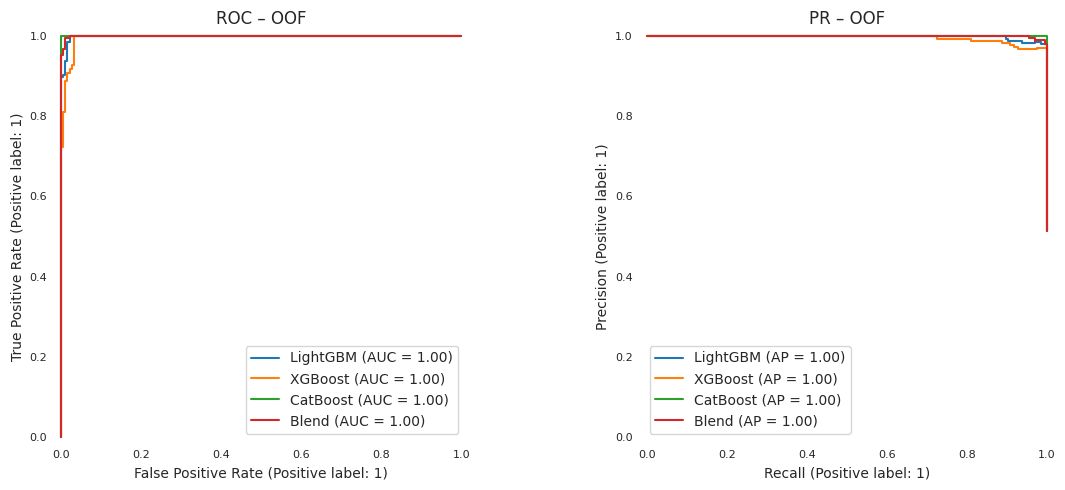

In [27]:
# ------------------------------------------------------------------
# 可视化 – ROC & PR 曲线
# ------------------------------------------------------------------
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    RocCurveDisplay.from_predictions(y, prob, name=label, ax=ax[0])
ax[0].set_title('ROC – OOF')

# PR
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    PrecisionRecallDisplay.from_predictions(y, prob, name=label, ax=ax[1])
ax[1].set_title('PR – OOF')

plt.tight_layout()
save('roc_pr')
plt.show()  # 显示图片
plt.close()

正在绘制 ROC/PR 曲线...


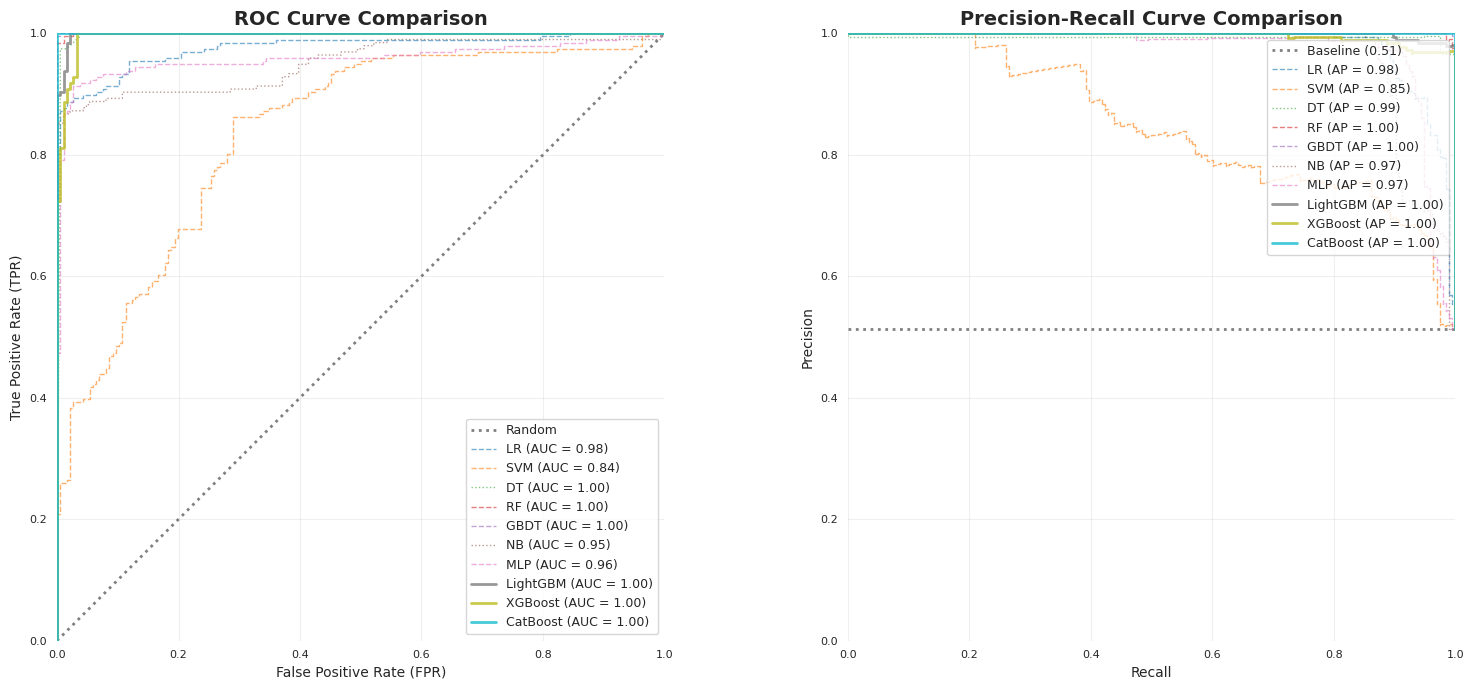

In [28]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import os

plot_data = [
    # --- 基础模型 (Sklearn) ---
    (oof_lr,   'LR',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_svm,  'SVM',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_dt,   'DT',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_rf,   'RF',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_gbdt, 'GBDT', {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_nb,   'NB',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_mlp,  'MLP',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    
    # --- 提升树模型 (Boosting) ---
    (oof_lgb,  'LightGBM', {'lw': 2, 'alpha': 0.8}),
    (oof_xgb,  'XGBoost',  {'lw': 2, 'alpha': 0.8}),
    (oof_cat,  'CatBoost', {'lw': 2, 'alpha': 0.8}),
    
    # （本图仅绘制你要求的 10 个模型 + random baseline，不额外绘制融合模型）
]

# 2. 设置绘图环境
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

# 创建画布
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 3. 循环绘图
print("正在绘制 ROC/PR 曲线...")

# --- ROC 曲线 ---
ax[0].plot([0, 1], [0, 1], linestyle=':', lw=2, color='gray', label='Random') # 对角线
for prob, label, kwargs in plot_data:
    RocCurveDisplay.from_predictions(
        y, prob, 
        name=label, 
        ax=ax[0], 
        plot_chance_level=False, # 手动画了对角线，这里关掉
        **kwargs
    )

ax[0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax[0].set_xlabel('False Positive Rate (FPR)')
ax[0].set_ylabel('True Positive Rate (TPR)')
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='lower right', fontsize=9)

# --- PR 曲线 ---
# 计算基准线 (Positive Rate)
baseline = y.sum() / len(y)
ax[1].plot([0, 1], [baseline, baseline], linestyle=':', lw=2, color='gray', label=f'Baseline ({baseline:.2f})')

for prob, label, kwargs in plot_data:
    PrecisionRecallDisplay.from_predictions(
        y, prob, 
        name=label, 
        ax=ax[1], 
        plot_chance_level=False,
        **kwargs
    )

ax[1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='upper right', fontsize=9)

# 4. 保存与展示
plt.tight_layout()
save('roc_pr_all_models')
plt.show()
plt.close()

正在筛选最佳单模型...

>>> 最佳模型: 【CatBoost】
>>> 最佳 F1 : 1.0000
>>> 最佳阈值: 0.9711


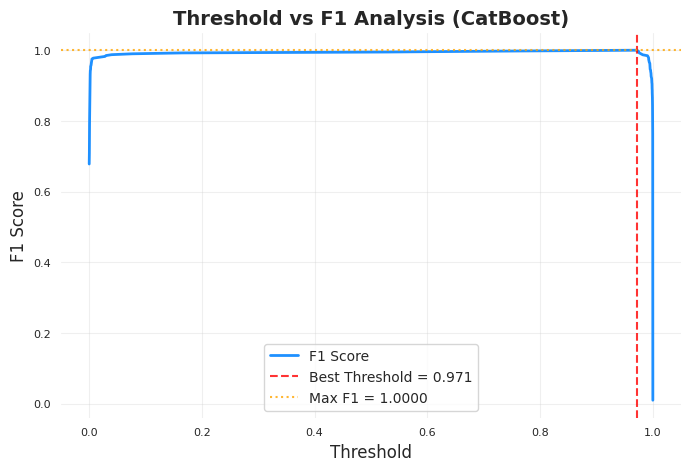

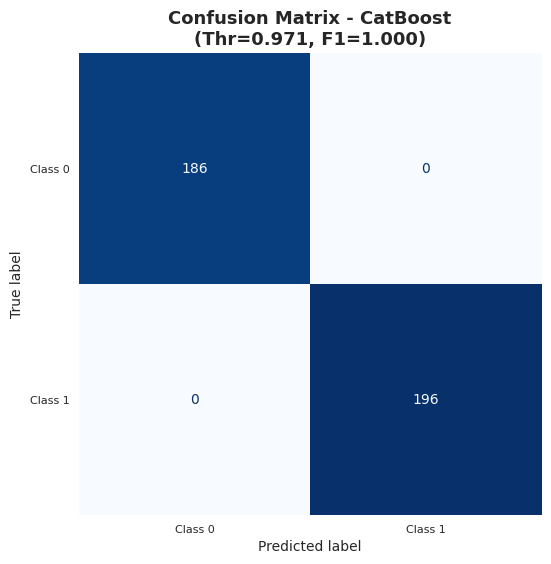

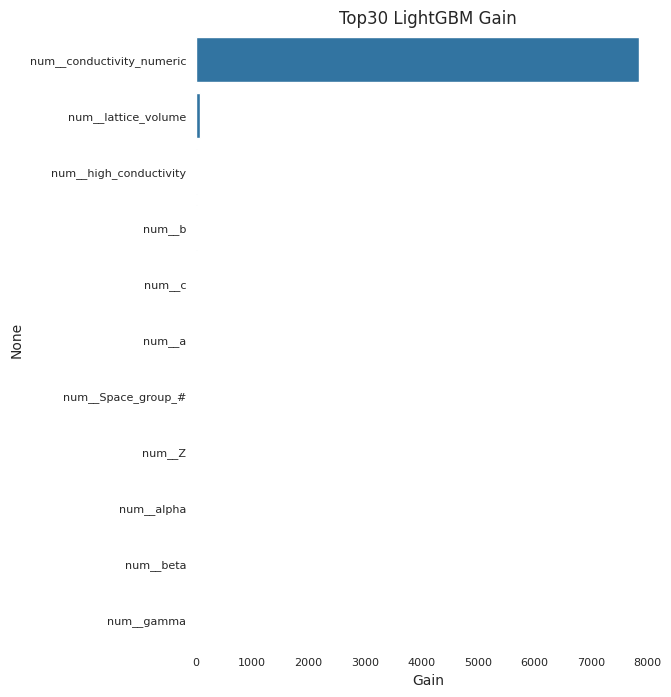

In [29]:
# ======================================================
# 1. 筛选最好单模
# ======================================================
candidates = {
    'Logistic Regression': oof_lr,
    'SVM': oof_svm,
    'Decision Tree': oof_dt,
    'Random Forest': oof_rf,
    'GBDT': oof_gbdt,
    'Naive Bayes': oof_nb,
    'MLP': oof_mlp,
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat
}

best_model_name = None
best_model_oof = None
global_best_f1 = -1
global_best_thr = -1

print("正在筛选最佳单模型...")
for name, oof_pred in candidates.items():
    # 计算该模型下的最佳阈值和F1
    p, r, t = precision_recall_curve(y, oof_pred)
    f1_scores = 2 * (p * r) / (p + r + 1e-8)

    idx = np.argmax(f1_scores)
    current_max_f1 = f1_scores[idx]
    
    current_best_thr = t[idx] if idx < len(t) else t[-1]
    
    if current_max_f1 > global_best_f1:
        global_best_f1 = current_max_f1
        global_best_thr = current_best_thr
        best_model_name = name
        best_model_oof = oof_pred

print(f"\n>>> 最佳模型: 【{best_model_name}】")
print(f">>> 最佳 F1 : {global_best_f1:.4f}")
print(f">>> 最佳阈值: {global_best_thr:.4f}")

# ======================================================
# 2. 绘制最佳单模型的 阈值-F1 曲线
# ======================================================
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

# 重新计算一遍胜出模型的数据用于绘图
precision, recall, thresholds = precision_recall_curve(y, best_model_oof)
f1s = 2 * (precision * recall) / (precision + recall + 1e-8)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1s[:-1], label='F1 Score', color='dodgerblue', linewidth=2)
plt.axvline(global_best_thr, color='red', linestyle='--', alpha=0.8, 
            label=f'Best Threshold = {global_best_thr:.3f}')
plt.axhline(global_best_f1, color='orange', linestyle=':', alpha=0.8, 
            label=f'Max F1 = {global_best_f1:.4f}')

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title(f'Threshold vs F1 Analysis ({best_model_name})', fontsize=14, fontweight='bold')
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)

save(f'threshold_f1_{best_model_name.replace(" ", "_")}') # 文件名带上模型名
plt.show()
plt.close()

# ======================================================
# 3. 绘制最佳单模型的 混淆矩阵
# ======================================================
# 使用最佳阈值将概率转为 0/1
pred_best_binary = (best_model_oof >= global_best_thr).astype(int)

cm = confusion_matrix(y, pred_best_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)

ax.set_title(f'Confusion Matrix - {best_model_name}\n(Thr={global_best_thr:.3f}, F1={global_best_f1:.3f})', 
             fontsize=13, fontweight='bold')

save(f'confusion_matrix_{best_model_name.replace(" ", "_")}')
plt.show()
plt.close()


# ========== 特征重要性（LightGBM示例） ==========
lgb_booster = m_lgb.booster_ if hasattr(m_lgb, 'booster_') else m_lgb
importance = lgb_booster.feature_importance(importance_type='gain')
feat_names = lgb_booster.feature_name()
imp_df = (pd.Series(importance, index=feat_names)
            .sort_values(ascending=False).head(30))
plt.figure(figsize=(6,8))
sns.barplot(x=imp_df.values, y=imp_df.index)
plt.title('Top30 LightGBM Gain'); plt.xlabel('Gain')
save('lgb_importance')
plt.show()  # 显示图片
plt.close()

>>> SHAP 解释性（最佳模型Catboost代表）


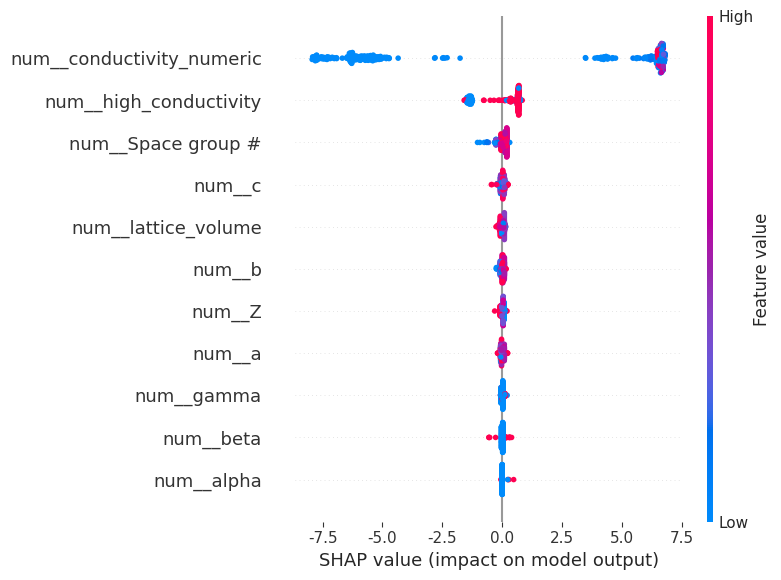

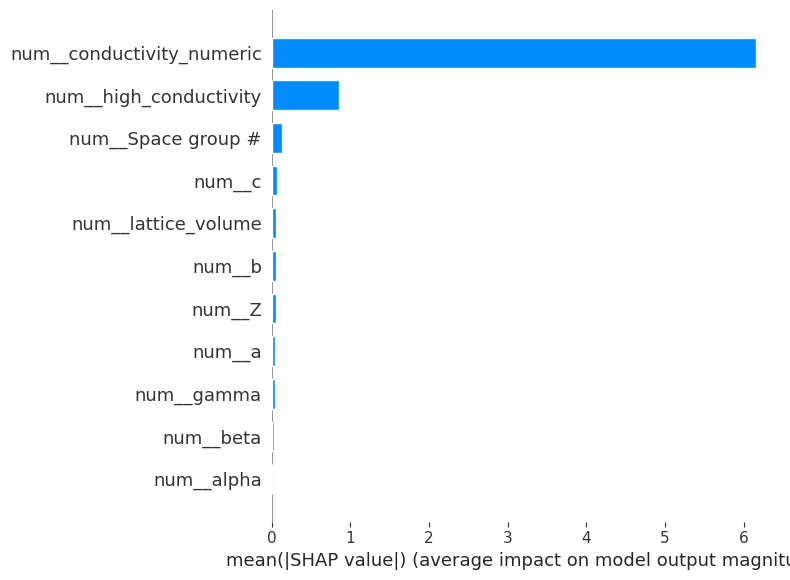

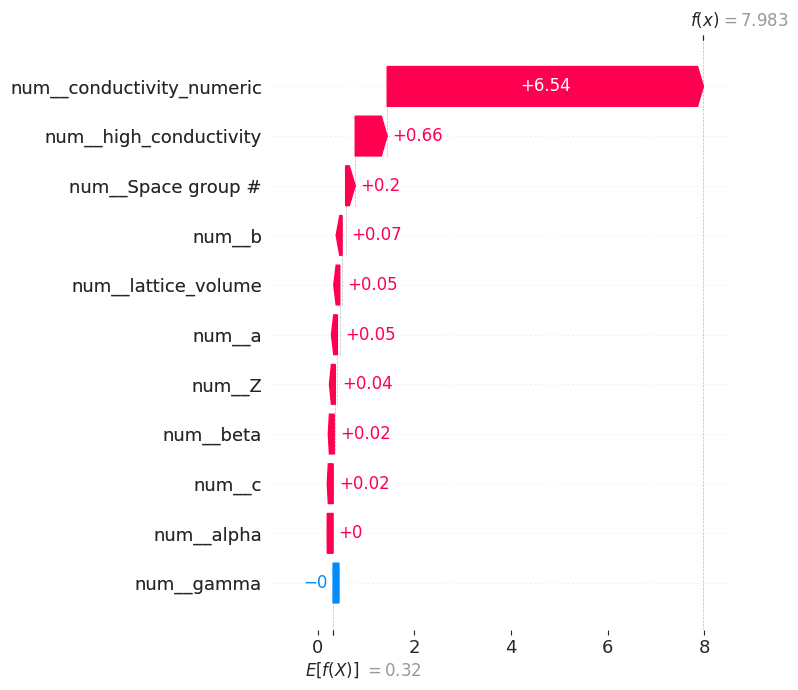

In [30]:
# ------------------------------------------------------------------
# SHAP 汇总（用最佳模型代表）
# ------------------------------------------------------------------

print('>>> SHAP 解释性（最佳模型Catboost代表）')
explainer = shap.TreeExplainer(m_cat)          # 也可用 m_xgb / m_lgb
sample_num = None  # 设为整数如 2000 可加速；None 表示全量
if sample_num is None:
    X_shap = X_full
else:
    X_shap = X_full.iloc[:sample_num] if hasattr(X_full, 'iloc') else X_full[:sample_num]
sample_idx = 0  # 瀑布图示例样本索引
shap_values = explainer.shap_values(X_shap)

# 兼容 CatBoost 二分类返回 list 的 shap_values
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    shap_summary_values = np.mean(np.array(shap_values), axis=0)
else:
    shap_plot_values = shap_values
    shap_summary_values = shap_values

# 摘要图
shap.summary_plot(shap_plot_values, X_shap,
                  feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_summary.png", dpi=300)
save('shap_summary')
plt.show()  # 显示图片
plt.close()

# 条形图
shap.summary_plot(shap_plot_values, X_shap, plot_type="bar", feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_bar.png", dpi=300)
save('shap_bar')
plt.show()
plt.close()

# ====== 2. SHAP 依赖图（以最重要特征为例） ======
top_feat = np.abs(shap_summary_values).mean(axis=0).argmax()  # 最重要特征索引
shap.dependence_plot(top_feat, shap_plot_values, X_shap,
                     feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_dependence.png", dpi=300)
plt.close()

# ====== 2. SHAP 依赖图（以最重要特征为例） ======
top_feat = np.abs(shap_plot_values).mean(0).argmax()  # 最重要特征索引
shap.dependence_plot(top_feat, shap_plot_values, X_shap,
                     feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_dependence2.png", dpi=300)
plt.close()

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)) and len(base_value) > 1:
    base_value = base_value[1]

shap.waterfall_plot(
    shap.Explanation(values=shap_plot_values[sample_idx],
                     base_values=base_value,
                     feature_names=preprocess.get_feature_names_out()),
    max_display=20, show=False)
plt.tight_layout()
plt.savefig("figs/shap_waterfall1.png", dpi=300)
plt.close()

# ====== 3. SHAP 瀑布图（单样本示例） ======
shap.waterfall_plot(
    shap.Explanation(values=shap_plot_values[sample_idx],
                     base_values=explainer.expected_value,
                     feature_names=preprocess.get_feature_names_out()),
    max_display=20, show=False)
plt.tight_layout()
plt.savefig("figs/shap_waterfall.png", dpi=300)
save('shap_waterfall')
plt.show()  # 显示图片
plt.close()